# Subplate thickness analysis

Whole-brain mean thickness = mean Euclidean distance between corresponding vertices of the WM surface (`*.wm..obj`, outer SP) and inner SP surface (`*.innersp.obj`), after applying `recon_native.xfm` so values are in native mm.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../../data/thickness_audit.csv')
df = df.dropna(subset=['wholebrain_thk_mean']).copy()
print(f'Rows with thickness: {len(df)}')
print(f'Unique subjects   : {df.subject_id.nunique()}')
df.head()

Rows with thickness: 60
Unique subjects   : 17


,subject_id,session_id,split,xfm_scale_x,xfm_scale_y,xfm_scale_z,lh_thk_n_vertices,lh_thk_mean,lh_thk_median,lh_thk_std,...,rh_thk_p95,rh_thk_max,wholebrain_thk_mean,GA,split_pair,thk_diff,thk_mean,apd_thk,qa_mean,stack_count
1,1109332,MR-EI_Fetal_Body-26810110-20230404,S2,0.853789,0.882943,0.904957,40962.0,2.602481,2.576815,1.065180,...,4.855021,6.117507,2.664798,27.00,S1-S2,NaN,NaN,NaN,0.54,3
2,1109332,MR-EI_Fetal_Body-26810110-20230404,S3,0.854776,0.884999,0.904278,40962.0,2.602244,2.577660,1.088328,...,4.835090,6.136756,2.633794,27.00,S3-S4,NaN,NaN,NaN,0.58,3
4,FCB145,2019.03.20-032Y-MR_EI_Fetal_Neuro-29197,S1,0.928738,0.963721,0.972594,40962.0,3.289396,3.115679,1.468418,...,6.211004,9.502054,3.328510,27.71,S1-S2,0.113109,3.271956,3.456909,0.83,3
5,FCB145,2019.03.20-032Y-MR_EI_Fetal_Neuro-29197,S2,0.929000,0.962499,0.978517,40962.0,3.327311,3.159044,1.472738,...,5.833292,8.180405,3.215401,27.71,S1-S2,0.113109,3.271956,3.456909,0.83,3
6,FCB145,2019.03.20-032Y-MR_EI_Fetal_Neuro-29197,S3,0.927694,0.963615,0.973314,40962.0,2.452147,2.431088,1.365692,...,6.353770,9.423003,2.943473,27.71,S3-S4,0.350504,3.118725,11.238703,0.79,3


In [2]:
# Summary stats
print('Whole-brain thickness (mm) by split:')
print(df.groupby('split')['wholebrain_thk_mean'].agg(['count','mean','std','min','max']).round(3))
print('\nLH vs RH (mm):')
print(df[['lh_thk_mean','rh_thk_mean']].describe().round(3))

Whole-brain thickness (mm) by split:
       count   mean    std    min    max
split                                   
S1        15  2.932  0.587  1.998  3.660
S2        15  2.865  0.566  1.960  3.741
S3        16  2.854  0.544  1.990  3.774
S4        14  2.791  0.509  1.933  3.416

LH vs RH (mm):
       lh_thk_mean  rh_thk_mean
count       60.000       60.000
mean         2.816        2.907
std          0.565        0.538
min          1.894        1.967
25%          2.228        2.353
50%          2.885        3.030
75%          3.281        3.359
max          3.898        3.684


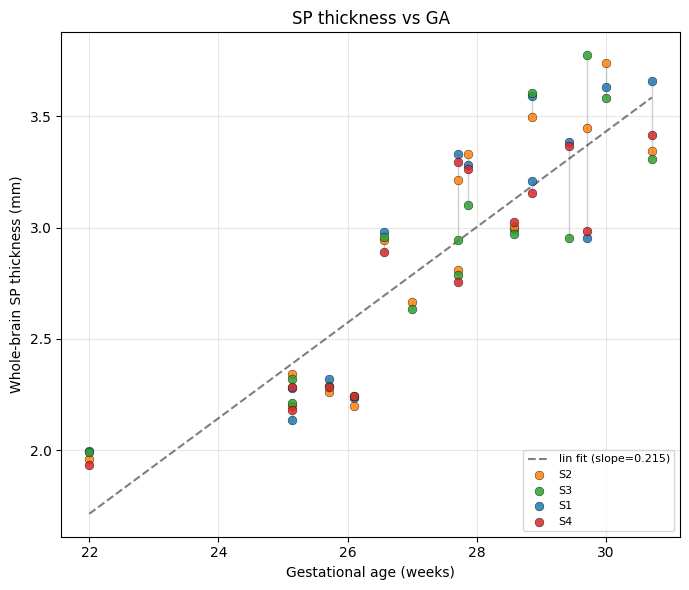

Pearson r (GA vs thickness) = +0.887


In [3]:
# Plot 1: thickness vs GA — points grouped per subject (vertical line connecting splits) and labeled by subject_id
split_colors = {'S1': '#1f77b4', 'S2': '#ff7f0e', 'S3': '#2ca02c', 'S4': '#d62728'}
fig, ax = plt.subplots(figsize=(7, 6))

# linear fit on all points
z = np.polyfit(df['GA'], df['wholebrain_thk_mean'], 1)
xs = np.linspace(df['GA'].min(), df['GA'].max(), 100)
ax.plot(xs, np.polyval(z, xs), 'k--', alpha=0.5, label=f'lin fit (slope={z[0]:.3f})')

# per subject: connect splits with a thin vertical line + label
seen_split_labels = set()
for sid, g in df.groupby('subject_id'):
    ga = g['GA'].iloc[0]
    ys = g['wholebrain_thk_mean'].values
    # vertical connector
    ax.plot([ga, ga], [ys.min(), ys.max()], color='grey', alpha=0.4, linewidth=1, zorder=1)
    # one dot per split (colored)
    for _, r in g.iterrows():
        lbl = r['split'] if r['split'] not in seen_split_labels else None
        seen_split_labels.add(r['split'])
        ax.scatter(ga, r['wholebrain_thk_mean'],
                   color=split_colors.get(r['split'], 'black'),
                   s=40, alpha=0.85, edgecolor='black', linewidth=0.3,
                   label=lbl, zorder=3)
    # # label with subject id, offset slightly to the right of the top dot
    # ax.annotate(sid, xy=(ga, ys.max()), xytext=(4, 4),
    #             textcoords='offset points', fontsize=7, alpha=0.85)

ax.set_xlabel('Gestational age (weeks)')
ax.set_ylabel('Whole-brain SP thickness (mm)')
ax.set_title('SP thickness vs GA')
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../../assets/artifacts/thickness_01_vs_ga.png', dpi=120)
plt.show()
r = df[['GA', 'wholebrain_thk_mean']].corr().iloc[0, 1]
print(f'Pearson r (GA vs thickness) = {r:+.3f}')

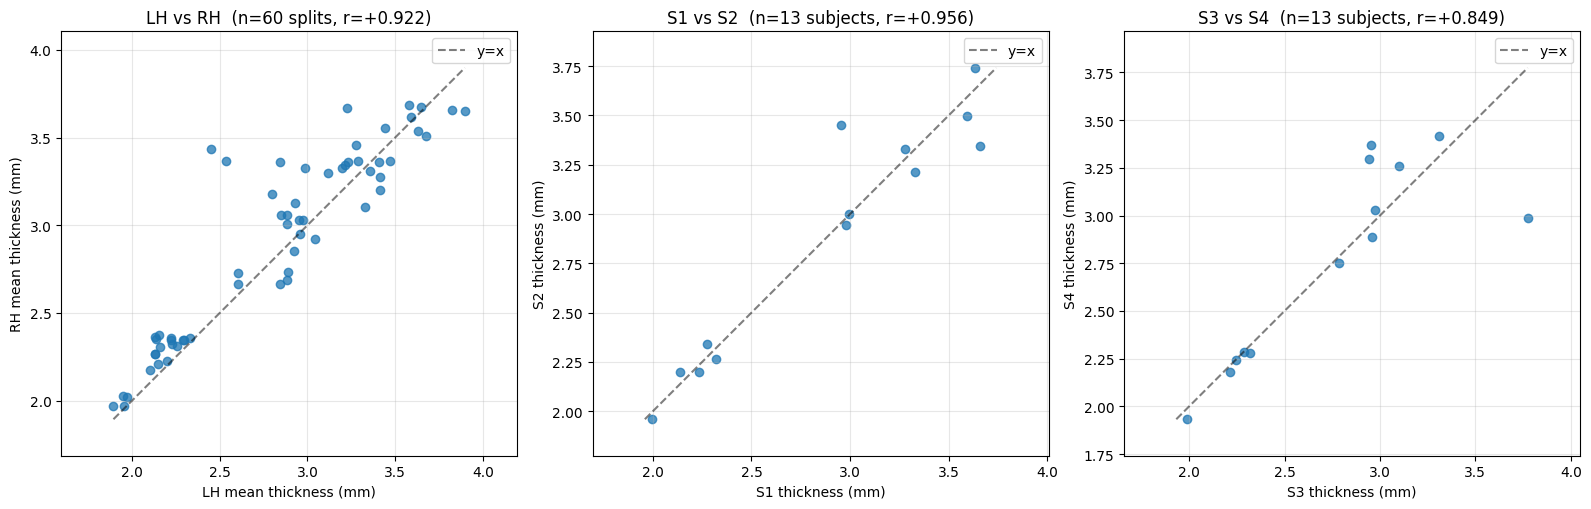

Mean |LH-RH| asymmetry = 0.163 mm
S1 vs S2: n=13, mean |Δ|=0.113 mm, max |Δ|=0.495 mm
S3 vs S4: n=13, mean |Δ|=0.162 mm, max |Δ|=0.788 mm


In [4]:
# Plot 2: agreement plots — LH vs RH (all rows), S1 vs S2 (per-subject pairs), S3 vs S4 (per-subject pairs).
# Split-pair plots use only subjects that have BOTH splits in the pair; report n comparisons.

def _agreement(ax, x, y, xlabel, ylabel, title):
    ax.scatter(x, y, alpha=0.75)
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.5, label='y=x')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_aspect('equal', adjustable='datalim')

pivot = df.pivot_table(index='subject_id', columns='split',
                       values='wholebrain_thk_mean', aggfunc='first')

fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))

# (a) LH vs RH — every subject/split row contributes
r_lhrh = df[['lh_thk_mean', 'rh_thk_mean']].corr().iloc[0, 1]
_agreement(axes[0], df['lh_thk_mean'], df['rh_thk_mean'],
           'LH mean thickness (mm)', 'RH mean thickness (mm)',
           f'LH vs RH  (n={len(df)} splits, r={r_lhrh:+.3f})')

# (b) S1 vs S2 — subjects with both
for ax, (a, b) in zip(axes[1:], [('S1', 'S2'), ('S3', 'S4')]):
    if a in pivot.columns and b in pivot.columns:
        pair = pivot[[a, b]].dropna()
        if len(pair) > 1:
            r_pair = pair.corr().iloc[0, 1]
            _agreement(ax, pair[a], pair[b],
                       f'{a} thickness (mm)', f'{b} thickness (mm)',
                       f'{a} vs {b}  (n={len(pair)} subjects, r={r_pair:+.3f})')
        else:
            ax.set_title(f'{a} vs {b}  (n={len(pair)} subjects — insufficient)')
    else:
        ax.set_title(f'{a} vs {b}  (no data)')

plt.tight_layout()
plt.savefig('../../assets/artifacts/thickness_02_lh_vs_rh.png', dpi=120)
plt.show()

print(f'Mean |LH-RH| asymmetry = {(df.lh_thk_mean - df.rh_thk_mean).abs().mean():.3f} mm')
for a, b in [('S1', 'S2'), ('S3', 'S4')]:
    pair = pivot[[a, b]].dropna()
    if len(pair):
        diff = (pair[a] - pair[b]).abs()
        print(f'{a} vs {b}: n={len(pair)}, mean |Δ|={diff.mean():.3f} mm, max |Δ|={diff.max():.3f} mm')

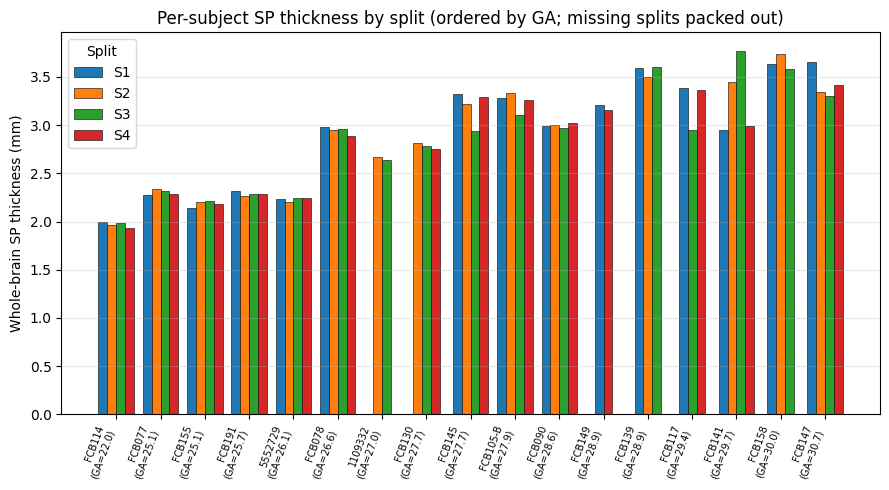

Subjects shown: 17
Splits-missing-per-subject distribution:
0    11
1     4
2     2


In [5]:
# Plot 3: bar plot ordered by GA — bars packed within each subject (no gap for missing splits)
splits = ['S1', 'S2', 'S3', 'S4']
split_colors = {'S1': '#1f77b4', 'S2': '#ff7f0e', 'S3': '#2ca02c', 'S4': '#d62728'}
subj_order = df.groupby('subject_id')['GA'].first().sort_values().index.tolist()
pivot = (df.pivot_table(index='subject_id', columns='split',
                        values='wholebrain_thk_mean', aggfunc='first')
           .reindex(subj_order))
ga_by_subj = df.groupby('subject_id')['GA'].first().reindex(subj_order)

# Fixed bar width — same regardless of how many splits a subject has.
# Within each subject, present splits are packed and the group is centered on x.
bar_w = 0.8 / len(splits)
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(subj_order))

legend_seen = set()
for i, sid in enumerate(subj_order):
    present = [s for s in splits if s in pivot.columns and pd.notna(pivot.loc[sid, s])]
    if not present:
        continue
    group_w = bar_w * len(present)
    start = x[i] - group_w / 2 + bar_w / 2
    for k, s in enumerate(present):
        lbl = s if s not in legend_seen else None
        legend_seen.add(s)
        ax.bar(start + k * bar_w, pivot.loc[sid, s], width=bar_w,
               color=split_colors[s], edgecolor='black', linewidth=0.4, label=lbl)

ax.set_xticks(x)
ax.set_xticklabels([f"{sid}\n(GA={ga:.1f})" for sid, ga in zip(subj_order, ga_by_subj)],
                   rotation=70, ha='right', fontsize=7)
ax.set_ylabel('Whole-brain SP thickness (mm)')
ax.set_title('Per-subject SP thickness by split (ordered by GA; missing splits packed out)')
# legend with consistent S1..S4 ordering
handles, labels = ax.get_legend_handles_labels()
ordered = sorted(zip(labels, handles), key=lambda lh: splits.index(lh[0]))
ax.legend([h for _, h in ordered], [l for l, _ in ordered], title='Split', loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../../assets/artifacts/thickness_03_bars_by_ga.png', dpi=120)
plt.show()
print(f'Subjects shown: {len(subj_order)}')
print('Splits-missing-per-subject distribution:')
print(pivot.isna().sum(axis=1).value_counts().sort_index().to_string())

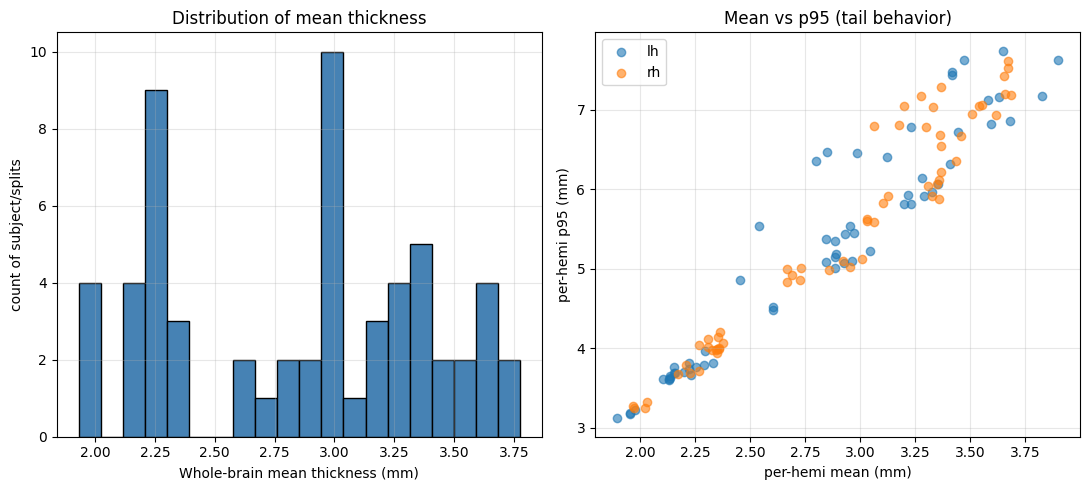

In [6]:
# Plot 4: distribution of per-vertex thickness statistics — median vs mean (should be close if symmetric)
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].hist(df['wholebrain_thk_mean'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Whole-brain mean thickness (mm)')
axes[0].set_ylabel('count of subject/splits')
axes[0].set_title('Distribution of mean thickness')
axes[0].grid(alpha=0.3)
for hemi, color in [('lh', 'tab:blue'), ('rh', 'tab:orange')]:
    axes[1].scatter(df[f'{hemi}_thk_mean'], df[f'{hemi}_thk_p95'], alpha=0.6, label=hemi, color=color)
axes[1].set_xlabel('per-hemi mean (mm)')
axes[1].set_ylabel('per-hemi p95 (mm)')
axes[1].set_title('Mean vs p95 (tail behavior)')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../../assets/artifacts/thickness_04_distributions.png', dpi=120)
plt.show()

## Thickness reliability models

Same modeling framework as the volume (`M_GA`/`M_acq`) and surface-area (`S_GA`/`S_acq`) models in `paper_models.ipynb`, applied here to **whole-brain mean SP thickness**.

Outcome: within-pair absolute thickness difference `thk_diff = |thk_a − thk_b|` (mm).
Predictors per paper: `GA`, `qa_mean` (mean quality across the pair), `stack_count`.

Two split pairs (S1-S2, S3-S4) treated as independent replications, fit separately. Read the results as *consistency across pairs*, not which pair has the highest R².

Only subjects with both splits of a pair contribute (N = 13 per pair). All thickness subjects are GA ≤ 32 wk, so no GA restriction is needed here.

Diagnostics (predicted vs actual, residuals vs fitted, QQ-plot, residuals vs GA) are shown directly under each model's forest plot.

### Build per-pair analysis frames

The comparative metrics live directly in `thickness_audit.csv` (columns `split_pair`, `thk_diff`, `thk_mean`, `apd_thk`) alongside the acquisition covariates (`qa_mean`, `stack_count`) — so the models read straight from that one file. Each split row carries its pair's values; we filter by `split_pair` and keep one row per subject-session.

In [7]:
import sys
from pathlib import Path

import statsmodels.api as sm
from IPython.display import display

sys.path.insert(0, '..')  # src/ — for slides_helpers
from slides_helpers import diagnostics_grid, fit_and_present, model_comparison_table

ASSETS = Path('../../assets/artifacts')

# thickness_audit.csv now carries the comparative columns directly
audit = pd.read_csv('../../data/thickness_audit.csv')


def get_pair(label):
    """One row per subject-session for a split pair, dropping incomplete pairs."""
    return (
        audit[audit['split_pair'] == label]
        .drop_duplicates(['subject_id', 'session_id'])
        .dropna(subset=['thk_diff'])
        .reset_index(drop=True)
    )


s12 = get_pair('S1-S2')
s34 = get_pair('S3-S4')

print('S1-S2 frame:', s12.shape, '| S3-S4 frame:', s34.shape)
display(s12[['subject_id', 'session_id', 'GA', 'thk_diff', 'thk_mean',
             'apd_thk', 'qa_mean', 'stack_count']].head(3))

S1-S2 frame: (13, 26) | S3-S4 frame: (13, 26)


,subject_id,session_id,GA,thk_diff,thk_mean,apd_thk,qa_mean,stack_count
0,FCB145,2019.03.20-032Y-MR_EI_Fetal_Neuro-29197,27.71,0.113109,3.271956,3.456909,0.83,3
1,FCB191,MR-EI_Fetal_Neuro-26708033-20230113,25.71,0.056648,2.291105,2.472508,0.53,5
2,FCB139,2019.01.31-032Y-MR_EI_Fetal_Neuro-29172,28.86,0.093669,3.545375,2.642015,0.85,5


### Layer 1 — Reliability magnitude (descriptive)

Paper-style summary: absolute and absolute-percent thickness difference (mean ± SD, range) for both pairs.

In [8]:
def reliability_row(df, pair):
    a = df['thk_diff'].dropna()
    p = df['apd_thk'].dropna()
    return {
        'metric': 'WB SP thickness (mm)', 'pair': pair, 'N': len(a),
        'abs_mean': a.mean().round(3), 'abs_sd': a.std().round(3),
        'abs_range': f'[{a.min():.3f}, {a.max():.3f}]',
        'APD_mean': p.mean().round(2), 'APD_sd': p.std().round(2),
        'APD_range': f'[{p.min():.2f}, {p.max():.2f}]',
    }

reliability_table = pd.DataFrame([
    reliability_row(s12, 'S1-S2'),
    reliability_row(s34, 'S3-S4'),
])
display(reliability_table)

,metric,pair,N,abs_mean,abs_sd,abs_range,APD_mean,APD_sd,APD_range
0,WB SP thickness (mm),S1-S2,13,0.113,0.138,"[0.009, 0.495]",3.70,4.10,"[0.29, 15.46]"
1,WB SP thickness (mm),S3-S4,13,0.162,0.228,"[0.000, 0.788]",5.19,6.77,"[0.00, 23.30]"


### Thickness models

Same two specifications as the volume/surface models, each fit independently for S1-S2 and S3-S4:
1. **T_GA** (baseline): `thk_diff ~ GA`
2. **T_acq** (paper-style acquisition factors): `thk_diff ~ GA + qa_mean + stack_count`


===  | S1-S2 | R²=0.313 | F=5.00 | p=0.0470 | N=13 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-0.749,0.387,-1.94,0.079,-1.6,0.10,
GA,0.032,0.014,2.24,0.047,0.0,0.06,*



===  | S3-S4 | R²=0.276 | F=4.19 | p=0.0652 | N=13 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-1.228,0.681,-1.80,0.099,-2.73,0.27,
GA,0.051,0.025,2.05,0.065,-0.00,0.11,


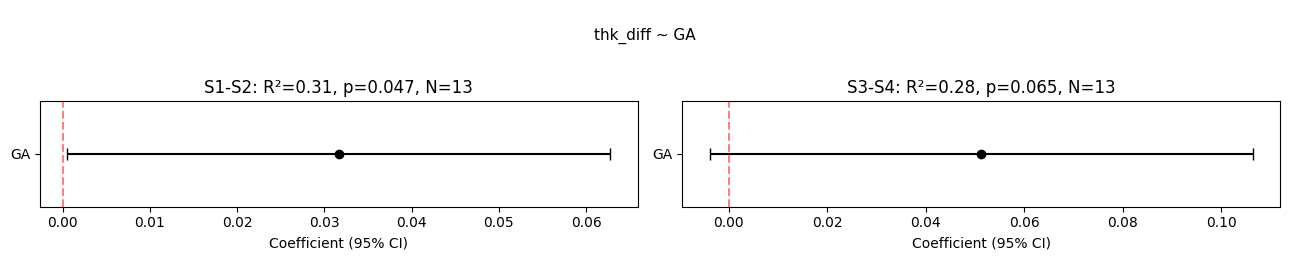

In [9]:
thk_results = {}

thk_results['T_GA (thk)'] = fit_and_present(
    'thk_diff', ['GA'], s12, s34,
    '', 'thk_T_GA', ASSETS, save_tables=False,
)


[T_GA — WB SP thickness baseline] S1-S2 — top 3 outliers (|studentized residual|):
  1. FCB141/2019.04.03-032Y-MR_EI_Fetal_Neuro-29199  studentized_resid=+2.78  resid=+0.303  fitted=0.192  actual=0.495
  2. FCB090/2016.07.24-029Y-MR_EI_Fetal_Neuro-12836  studentized_resid=-1.30  resid=-0.147  fitted=0.156  actual=0.00872
  3. FCB114/2017.06.26-027Y-MR_EI_Fetal_Neuro-17914  studentized_resid=+1.03  resid=+0.0904  fitted=-0.0523  actual=0.038

[T_GA — WB SP thickness baseline] S3-S4 — top 3 outliers (|studentized residual|):
  1. FCB141/2019.04.03-032Y-MR_EI_Fetal_Neuro-29199  studentized_resid=+2.68  resid=+0.492  fitted=0.296  actual=0.788
  2. FCB147/2019.05.08-036Y-MR_EI_Fetal_Neuro-29187  studentized_resid=-1.38  resid=-0.238  fitted=0.347  actual=0.109
  3. FCB114/2017.06.26-027Y-MR_EI_Fetal_Neuro-17914  studentized_resid=+1.06  resid=+0.157  fitted=-0.0995  actual=0.0572


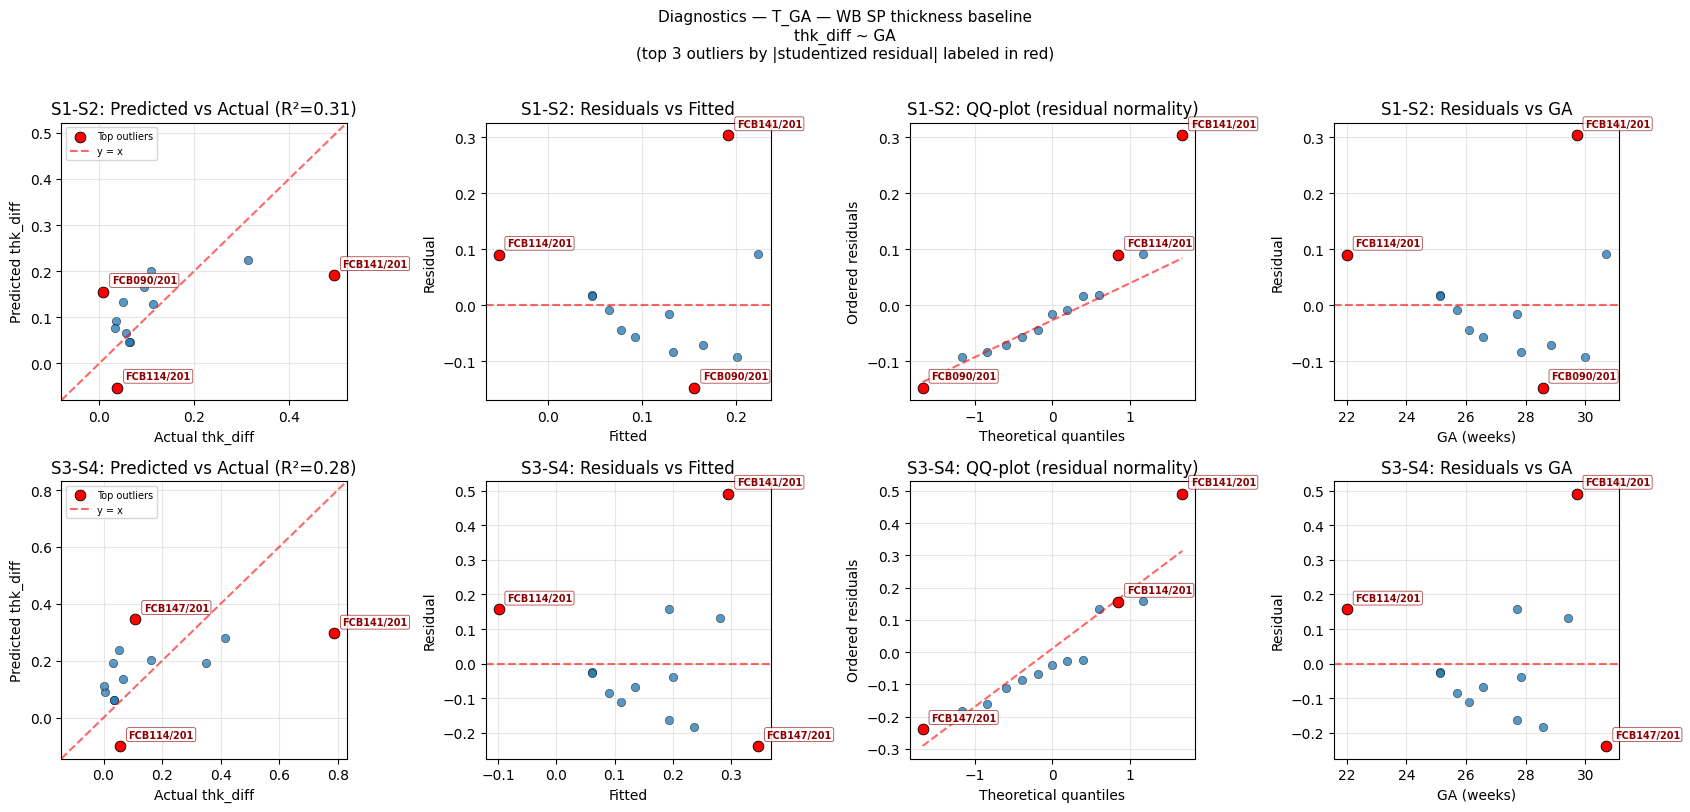

In [10]:
diagnostics_grid(
    thk_results['T_GA (thk)'], s12, s34,
    'thk_diff', ['GA'],
    'T_GA — WB SP thickness baseline',
)
plt.show()


===  | S1-S2 | R²=0.326 | F=1.45 | p=0.2910 | N=13 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-0.621,0.517,-1.20,0.260,-1.79,0.55,
GA,0.033,0.016,2.08,0.067,-0.00,0.07,
qa_mean,-0.163,0.398,-0.41,0.693,-1.06,0.74,
stack_count,-0.007,0.018,-0.37,0.721,-0.05,0.03,



===  | S3-S4 | R²=0.322 | F=1.43 | p=0.2984 | N=13 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-1.000,0.810,-1.23,0.248,-2.83,0.83,
GA,0.052,0.027,1.94,0.084,-0.01,0.11,
qa_mean,-0.159,0.444,-0.36,0.729,-1.16,0.85,
stack_count,-0.019,0.025,-0.78,0.455,-0.08,0.04,


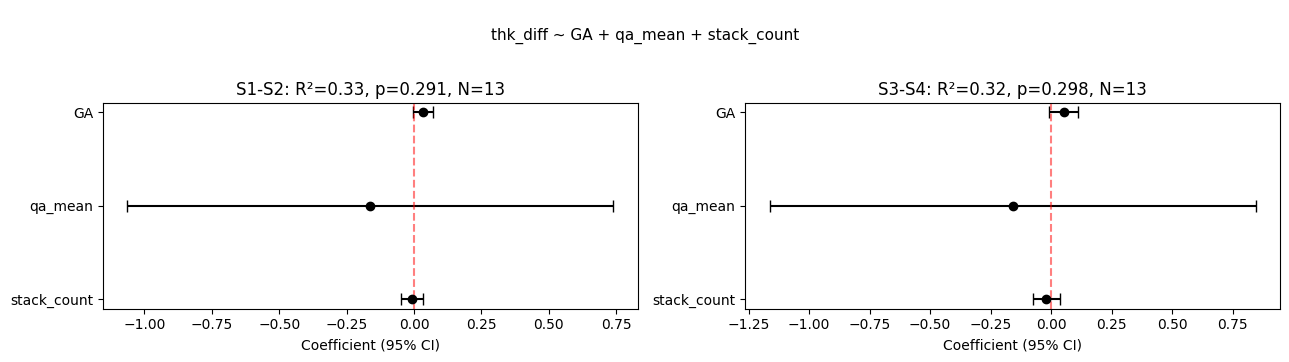

In [11]:
thk_results['T_acq (thk)'] = fit_and_present(
    'thk_diff', ['GA', 'qa_mean', 'stack_count'], s12, s34,
    '', 'thk_T_acq', ASSETS, save_tables=False,
)


[T_acq — WB SP thickness + acquisition factors] S1-S2 — top 3 outliers (|studentized residual|):
  1. FCB141/2019.04.03-032Y-MR_EI_Fetal_Neuro-29199  studentized_resid=+2.53  resid=+0.288  fitted=0.207  actual=0.495
  2. FCB090/2016.07.24-029Y-MR_EI_Fetal_Neuro-12836  studentized_resid=-1.29  resid=-0.148  fitted=0.157  actual=0.00872
  3. FCB147/2019.05.08-036Y-MR_EI_Fetal_Neuro-29187  studentized_resid=+1.04  resid=+0.107  fitted=0.208  actual=0.314

[T_acq — WB SP thickness + acquisition factors] S3-S4 — top 3 outliers (|studentized residual|):
  1. FCB141/2019.04.03-032Y-MR_EI_Fetal_Neuro-29199  studentized_resid=+2.48  resid=+0.483  fitted=0.305  actual=0.788
  2. FCB114/2017.06.26-027Y-MR_EI_Fetal_Neuro-17914  studentized_resid=+1.46  resid=+0.184  fitted=-0.127  actual=0.0572
  3. FCB130/2018.11.02-030Y-MR_EI_Fetal_Neuro-29188  studentized_resid=-1.31  resid=-0.236  fitted=0.268  actual=0.0313


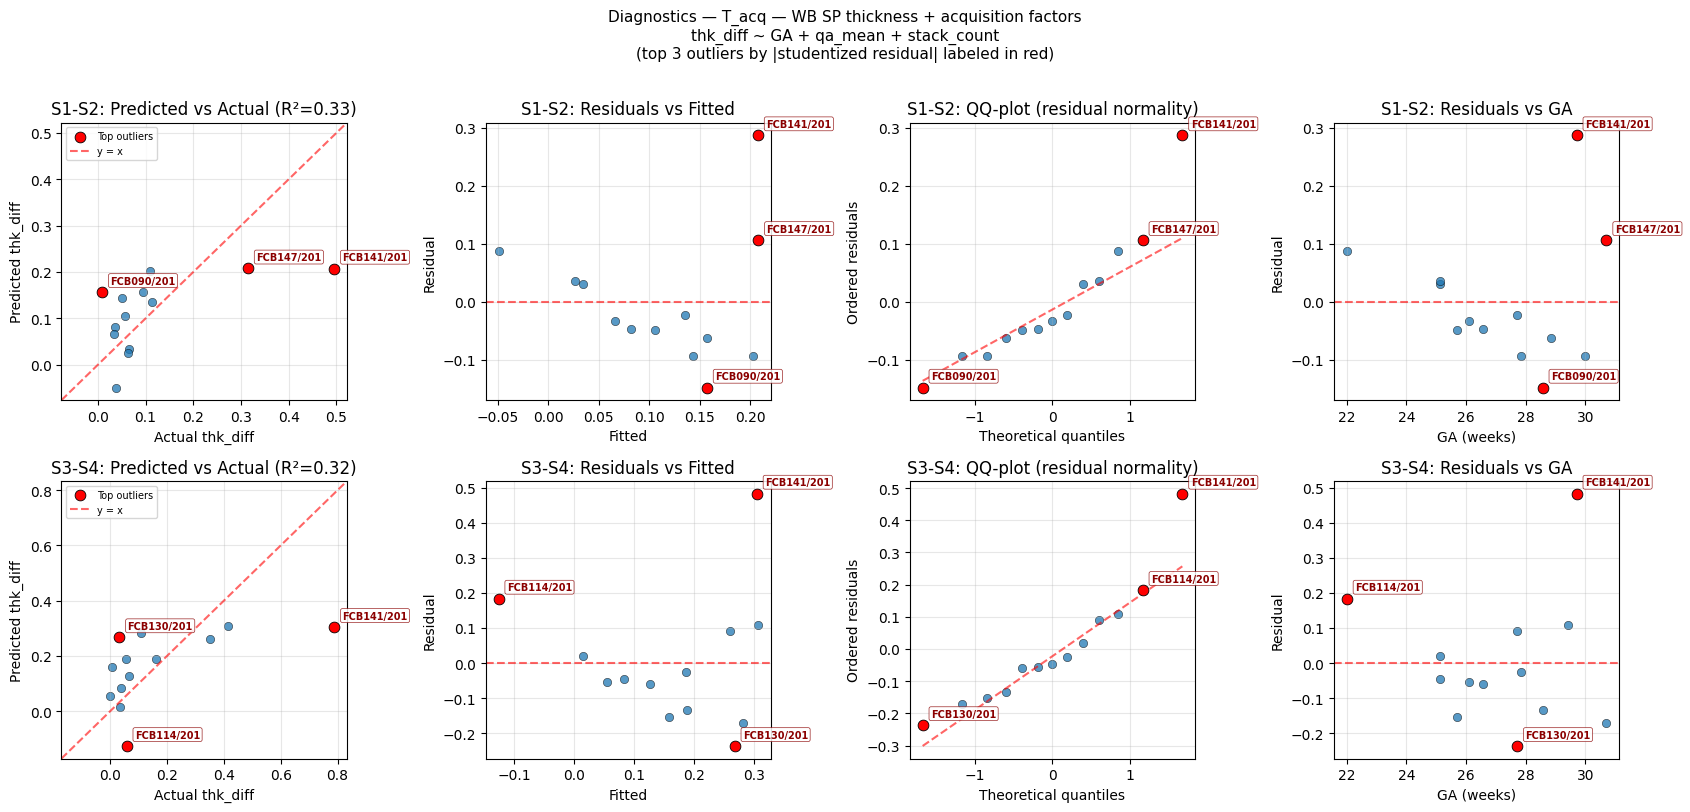

In [12]:
diagnostics_grid(
    thk_results['T_acq (thk)'], s12, s34,
    'thk_diff', ['GA', 'qa_mean', 'stack_count'],
    'T_acq — WB SP thickness + acquisition factors',
)
plt.show()

### Cross-model comparison

Side-by-side R², GA effect across both thickness models × both pairs. Read column-wise: a model is *consistent* if its R², GA-sign, and GA-significance look similar across S1-S2 and S3-S4.

,model,pair,N,R2,adj_R2,F_p,GA_coef,GA_p
0,T_GA (thk),S1-S2,13,0.313,0.250,0.0470,0.032,0.0470
1,T_GA (thk),S3-S4,13,0.276,0.210,0.0652,0.051,0.0652
2,T_acq (thk),S1-S2,13,0.326,0.102,0.2910,0.033,0.0672
3,T_acq (thk),S3-S4,13,0.322,0.096,0.2984,0.052,0.0841


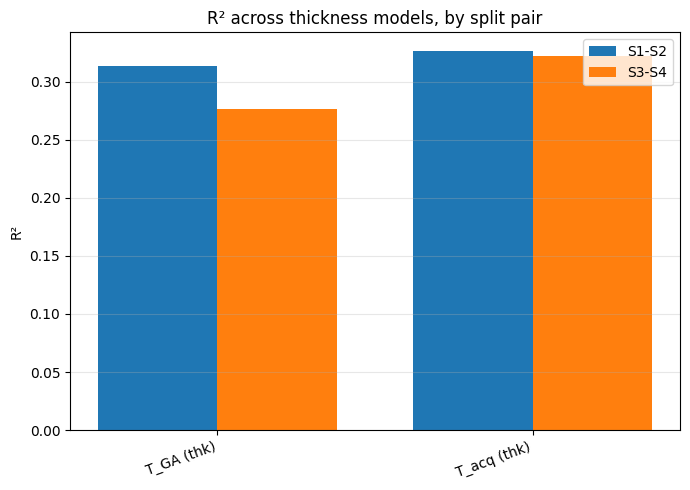

In [13]:
comparison = model_comparison_table(thk_results)
display(comparison)

# R^2 bar chart, paired by split
fig, ax = plt.subplots(figsize=(7, 5))
models = comparison['model'].unique()
x = np.arange(len(models))
w = 0.38
for i, pair in enumerate(['S1-S2', 'S3-S4']):
    sub = comparison[comparison['pair'] == pair].set_index('model').reindex(models)
    ax.bar(x + (i - 0.5) * w, sub['R2'], width=w, label=pair)
ax.set_xticks(x); ax.set_xticklabels(models, rotation=20, ha='right')
ax.set_ylabel('R²'); ax.set_title('R² across thickness models, by split pair')
ax.legend(); ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(ASSETS / 'thickness_model_comparison_R2.png', dpi=130, bbox_inches='tight')
plt.show()

## Sensitivity — drop the most common outliers

The cross-model outlier scan in `paper_models.ipynb` flagged **FCB141** and **FCB114** as among the most frequently-flagged subjects across the volume/surface/thickness fits. Here the thickness models are refit with those two subjects removed (N = 13 → 11 per pair) to check whether the GA signal is robust to them.

Read it the same way: *consistency across pairs*, and whether `R²` / GA-coefficient / GA-significance hold up once the outliers are gone.

In [14]:
DROP = ['FCB141', 'FCB114']

s12_f = s12[~s12['subject_id'].isin(DROP)].reset_index(drop=True)
s34_f = s34[~s34['subject_id'].isin(DROP)].reset_index(drop=True)

print('Dropped:', DROP)
print('Filtered frames — S1-S2:', s12_f.shape, '| S3-S4:', s34_f.shape)

Dropped: ['FCB141', 'FCB114']
Filtered frames — S1-S2: (11, 26) | S3-S4: (11, 26)



===  | S1-S2 | R²=0.390 | F=5.75 | p=0.0400 | N=11 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-0.652,0.308,-2.12,0.063,-1.35,0.05,
GA,0.027,0.011,2.40,0.040,0.00,0.05,*



===  | S3-S4 | R²=0.272 | F=3.36 | p=0.0999 | N=11 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-1.003,0.611,-1.64,0.135,-2.39,0.38,
GA,0.041,0.022,1.83,0.100,-0.01,0.09,


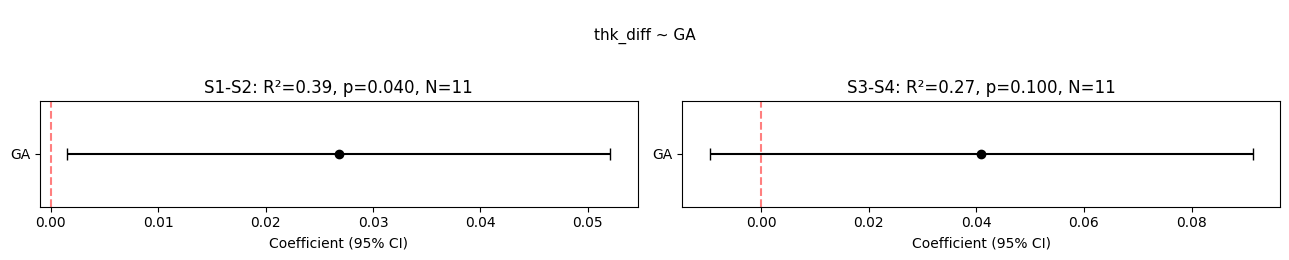

In [15]:
thk_results_f = {}

thk_results_f['T_GA (thk, -outliers)'] = fit_and_present(
    'thk_diff', ['GA'], s12_f, s34_f,
    '', 'thk_T_GA_filt', ASSETS, save_tables=False,
)


[T_GA — WB SP thickness (FCB141/FCB114 dropped)] S1-S2 — top 3 outliers (|studentized residual|):
  1. FCB147/2019.05.08-036Y-MR_EI_Fetal_Neuro-29187  studentized_resid=+2.65  resid=+0.142  fitted=0.172  actual=0.314
  2. FCB090/2016.07.24-029Y-MR_EI_Fetal_Neuro-12836  studentized_resid=-1.66  resid=-0.106  fitted=0.115  actual=0.00872
  3. FCB158/2019.07.07-034Y-MR_EI_Fetal_Neuro-29182  studentized_resid=-0.76  resid=-0.0443  fitted=0.153  actual=0.109

[T_GA — WB SP thickness (FCB141/FCB114 dropped)] S3-S4 — top 3 outliers (|studentized residual|):
  1. FCB117/2018.03.01-032Y-MR_EI_Fetal_Neuro-18053  studentized_resid=+1.92  resid=+0.214  fitted=0.201  actual=0.415
  2. FCB145/2019.03.20-032Y-MR_EI_Fetal_Neuro-29197  studentized_resid=+1.83  resid=+0.22  fitted=0.13  actual=0.351
  3. FCB147/2019.05.08-036Y-MR_EI_Fetal_Neuro-29187  studentized_resid=-1.53  resid=-0.144  fitted=0.253  actual=0.109


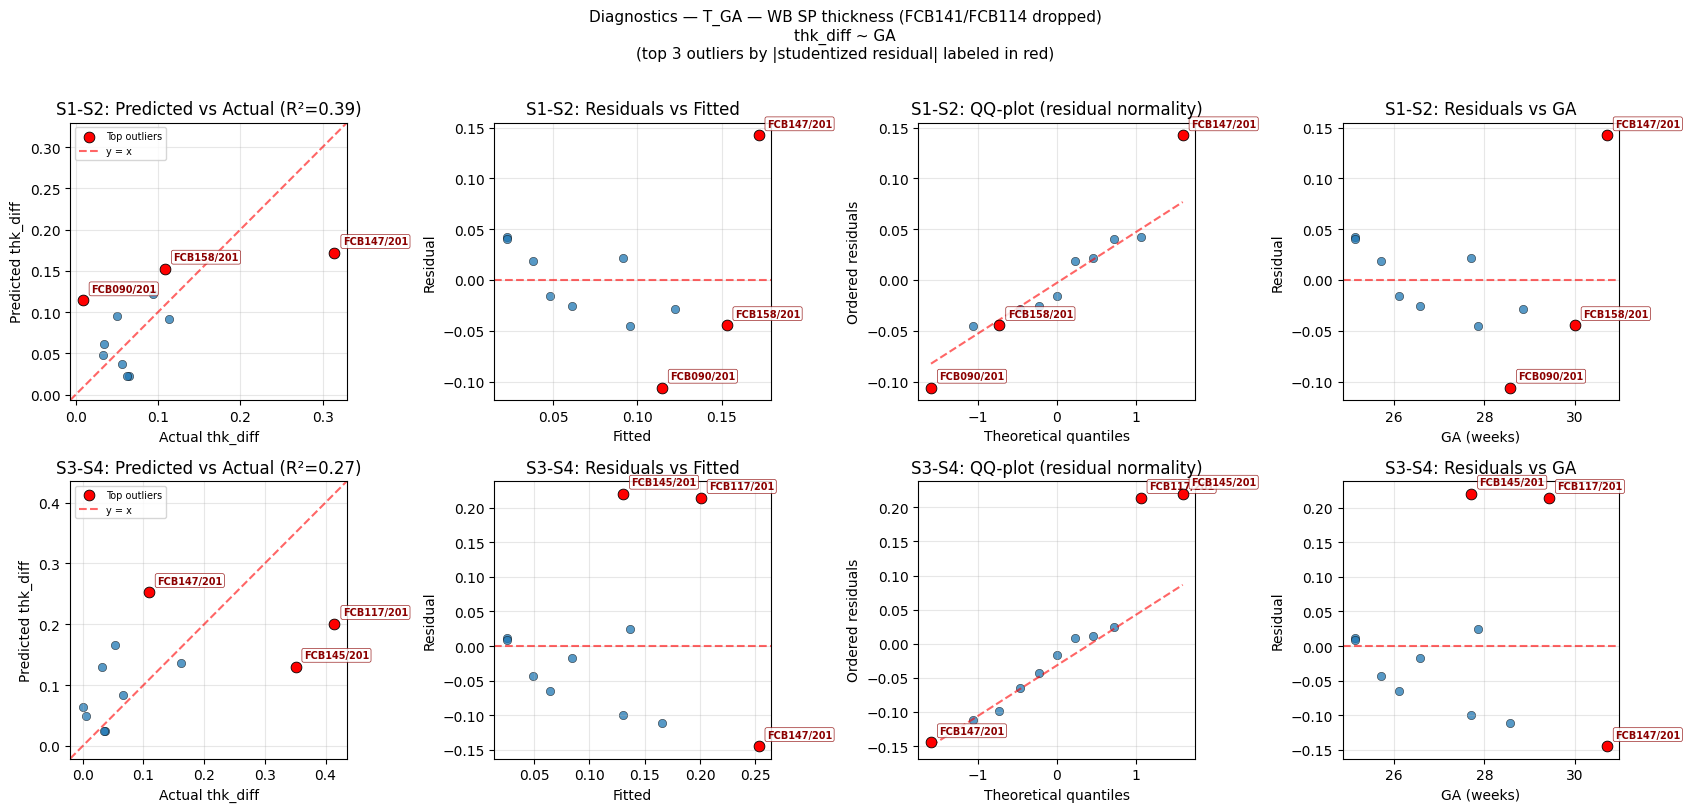

In [16]:
diagnostics_grid(
    thk_results_f['T_GA (thk, -outliers)'], s12_f, s34_f,
    'thk_diff', ['GA'],
    'T_GA — WB SP thickness (FCB141/FCB114 dropped)',
)
plt.show()


===  | S1-S2 | R²=0.449 | F=1.91 | p=0.2172 | N=11 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-0.817,0.383,-2.13,0.070,-1.72,0.09,
GA,0.027,0.013,2.13,0.071,-0.00,0.06,
qa_mean,0.197,0.238,0.83,0.435,-0.37,0.76,
stack_count,0.003,0.011,0.28,0.788,-0.02,0.03,



===  | S3-S4 | R²=0.423 | F=1.71 | p=0.2517 | N=11 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-1.029,0.789,-1.30,0.234,-2.89,0.84,
GA,0.050,0.026,1.91,0.098,-0.01,0.11,
qa_mean,-0.100,0.302,-0.33,0.751,-0.81,0.62,
stack_count,-0.021,0.016,-1.35,0.220,-0.06,0.02,


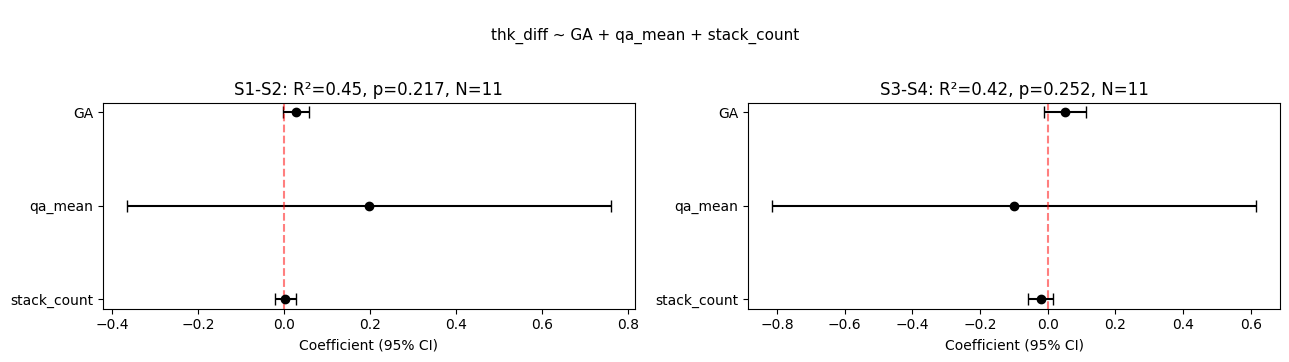

In [17]:
thk_results_f['T_acq (thk, -outliers)'] = fit_and_present(
    'thk_diff', ['GA', 'qa_mean', 'stack_count'], s12_f, s34_f,
    '', 'thk_T_acq_filt', ASSETS, save_tables=False,
)


[T_acq — WB SP thickness + acquisition (FCB141/FCB114 dropped)] S1-S2 — top 3 outliers (|studentized residual|):
  1. FCB147/2019.05.08-036Y-MR_EI_Fetal_Neuro-29187  studentized_resid=+2.50  resid=+0.136  fitted=0.178  actual=0.314
  2. FCB191/MR-EI_Fetal_Neuro-26708033-20230113  studentized_resid=+1.67  resid=+0.0592  fitted=-0.00251  actual=0.0566
  3. FCB090/2016.07.24-029Y-MR_EI_Fetal_Neuro-12836  studentized_resid=-1.40  resid=-0.0878  fitted=0.0965  actual=0.00872

[T_acq — WB SP thickness + acquisition (FCB141/FCB114 dropped)] S3-S4 — top 3 outliers (|studentized residual|):
  1. FCB117/2018.03.01-032Y-MR_EI_Fetal_Neuro-18053  studentized_resid=+2.10  resid=+0.192  fitted=0.223  actual=0.415
  2. FCB130/2018.11.02-030Y-MR_EI_Fetal_Neuro-29188  studentized_resid=-1.63  resid=-0.172  fitted=0.203  actual=0.0313
  3. FCB145/2019.03.20-032Y-MR_EI_Fetal_Neuro-29197  studentized_resid=+1.57  resid=+0.134  fitted=0.216  actual=0.351


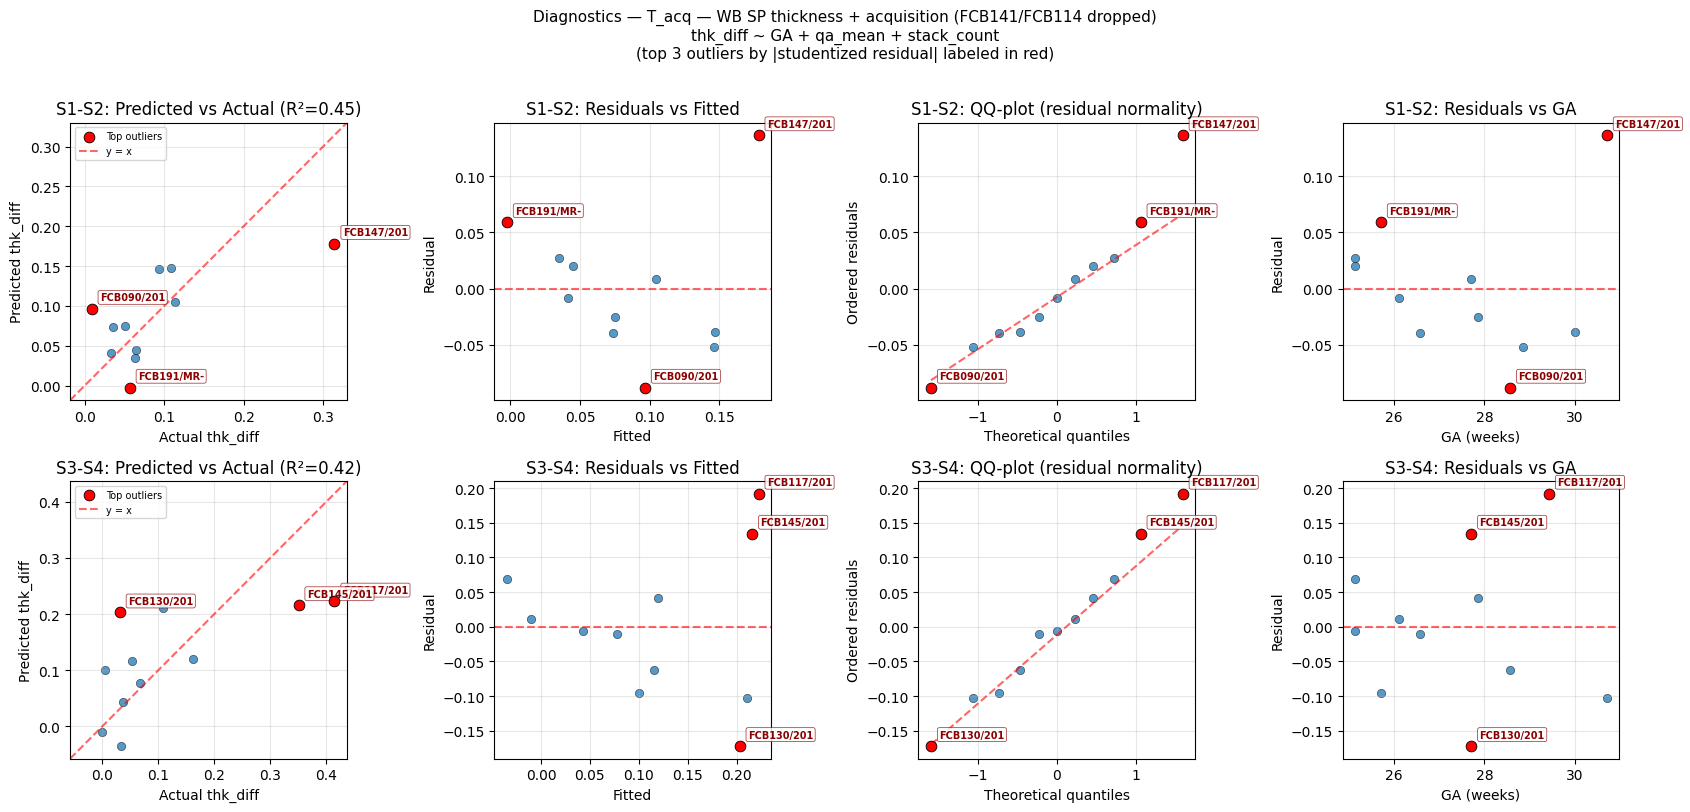

In [18]:
diagnostics_grid(
    thk_results_f['T_acq (thk, -outliers)'], s12_f, s34_f,
    'thk_diff', ['GA', 'qa_mean', 'stack_count'],
    'T_acq — WB SP thickness + acquisition (FCB141/FCB114 dropped)',
)
plt.show()

### Full sample vs. outliers-dropped

Side-by-side comparison of the two thickness models fit on the full sample (N = 13) and with FCB141/FCB114 removed (N = 11).

In [19]:
full = model_comparison_table(thk_results).assign(sample='full (N=13)')
filt = model_comparison_table(thk_results_f).assign(sample='drop FCB141/FCB114 (N=11)')
filt['model'] = filt['model'].str.replace(' (thk, -outliers)', ' (thk)', regex=False)

side = (pd.concat([full, filt], ignore_index=True)
          .sort_values(['model', 'pair', 'sample'])
          .reset_index(drop=True))
display(side[['model', 'pair', 'sample', 'N', 'R2', 'adj_R2', 'F_p', 'GA_coef', 'GA_p']])

,model,pair,sample,N,R2,adj_R2,F_p,GA_coef,GA_p
0,T_GA (thk),S1-S2,drop FCB141/FCB114 (N=11),11,0.390,0.322,0.0400,0.027,0.0400
1,T_GA (thk),S1-S2,full (N=13),13,0.313,0.250,0.0470,0.032,0.0470
2,T_GA (thk),S3-S4,drop FCB141/FCB114 (N=11),11,0.272,0.191,0.0999,0.041,0.0999
3,T_GA (thk),S3-S4,full (N=13),13,0.276,0.210,0.0652,0.051,0.0652
4,T_acq (thk),S1-S2,drop FCB141/FCB114 (N=11),11,0.449,0.214,0.2172,0.027,0.0710
5,T_acq (thk),S1-S2,full (N=13),13,0.326,0.102,0.2910,0.033,0.0672
6,T_acq (thk),S3-S4,drop FCB141/FCB114 (N=11),11,0.423,0.175,0.2517,0.050,0.0983
7,T_acq (thk),S3-S4,full (N=13),13,0.322,0.096,0.2984,0.052,0.0841


# Subplate thickness analysis

Whole-brain mean thickness = mean Euclidean distance between corresponding vertices of the WM surface (`*.wm..obj`, outer SP) and inner SP surface (`*.innersp.obj`), after applying `recon_native.xfm` so values are in native mm.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../../data/thickness_audit.csv')
df = df.dropna(subset=['wholebrain_thk_mean']).copy()
print(f'Rows with thickness: {len(df)}')
print(f'Unique subjects   : {df.subject_id.nunique()}')
df.head()

Rows with thickness: 60
Unique subjects   : 17


,subject_id,session_id,split,xfm_scale_x,xfm_scale_y,xfm_scale_z,lh_thk_n_vertices,lh_thk_mean,lh_thk_median,lh_thk_std,...,rh_thk_p95,rh_thk_max,wholebrain_thk_mean,GA,split_pair,thk_diff,thk_mean,apd_thk,qa_mean,stack_count
1,1109332,MR-EI_Fetal_Body-26810110-20230404,S2,0.853789,0.882943,0.904957,40962.0,2.602481,2.576815,1.065180,...,4.855021,6.117507,2.664798,27.00,S1-S2,NaN,NaN,NaN,0.54,3
2,1109332,MR-EI_Fetal_Body-26810110-20230404,S3,0.854776,0.884999,0.904278,40962.0,2.602244,2.577660,1.088328,...,4.835090,6.136756,2.633794,27.00,S3-S4,NaN,NaN,NaN,0.58,3
4,FCB145,2019.03.20-032Y-MR_EI_Fetal_Neuro-29197,S1,0.928738,0.963721,0.972594,40962.0,3.289396,3.115679,1.468418,...,6.211004,9.502054,3.328510,27.71,S1-S2,0.113109,3.271956,3.456909,0.83,3
5,FCB145,2019.03.20-032Y-MR_EI_Fetal_Neuro-29197,S2,0.929000,0.962499,0.978517,40962.0,3.327311,3.159044,1.472738,...,5.833292,8.180405,3.215401,27.71,S1-S2,0.113109,3.271956,3.456909,0.83,3
6,FCB145,2019.03.20-032Y-MR_EI_Fetal_Neuro-29197,S3,0.927694,0.963615,0.973314,40962.0,2.452147,2.431088,1.365692,...,6.353770,9.423003,2.943473,27.71,S3-S4,0.350504,3.118725,11.238703,0.79,3


In [2]:
# Summary stats
print('Whole-brain thickness (mm) by split:')
print(df.groupby('split')['wholebrain_thk_mean'].agg(['count','mean','std','min','max']).round(3))
print('\nLH vs RH (mm):')
print(df[['lh_thk_mean','rh_thk_mean']].describe().round(3))

Whole-brain thickness (mm) by split:
       count   mean    std    min    max
split                                   
S1        15  2.932  0.587  1.998  3.660
S2        15  2.865  0.566  1.960  3.741
S3        16  2.854  0.544  1.990  3.774
S4        14  2.791  0.509  1.933  3.416

LH vs RH (mm):
       lh_thk_mean  rh_thk_mean
count       60.000       60.000
mean         2.816        2.907
std          0.565        0.538
min          1.894        1.967
25%          2.228        2.353
50%          2.885        3.030
75%          3.281        3.359
max          3.898        3.684


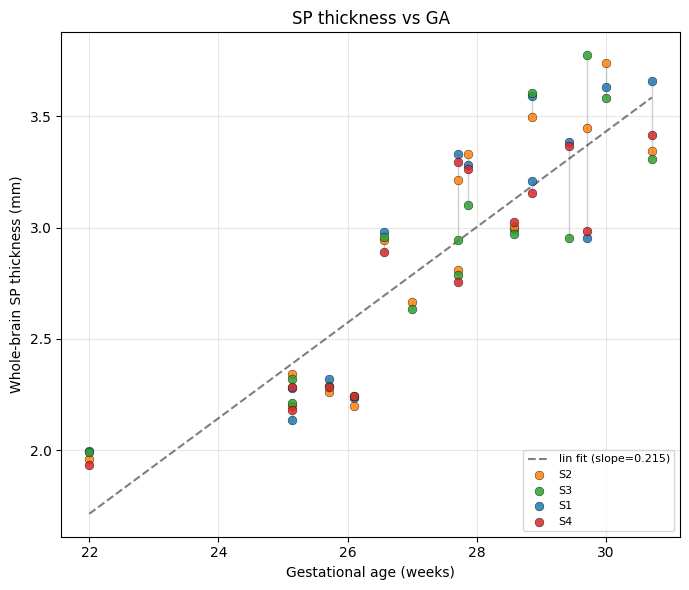

Pearson r (GA vs thickness) = +0.887


In [3]:
# Plot 1: thickness vs GA — points grouped per subject (vertical line connecting splits) and labeled by subject_id
split_colors = {'S1': '#1f77b4', 'S2': '#ff7f0e', 'S3': '#2ca02c', 'S4': '#d62728'}
fig, ax = plt.subplots(figsize=(7, 6))

# linear fit on all points
z = np.polyfit(df['GA'], df['wholebrain_thk_mean'], 1)
xs = np.linspace(df['GA'].min(), df['GA'].max(), 100)
ax.plot(xs, np.polyval(z, xs), 'k--', alpha=0.5, label=f'lin fit (slope={z[0]:.3f})')

# per subject: connect splits with a thin vertical line + label
seen_split_labels = set()
for sid, g in df.groupby('subject_id'):
    ga = g['GA'].iloc[0]
    ys = g['wholebrain_thk_mean'].values
    # vertical connector
    ax.plot([ga, ga], [ys.min(), ys.max()], color='grey', alpha=0.4, linewidth=1, zorder=1)
    # one dot per split (colored)
    for _, r in g.iterrows():
        lbl = r['split'] if r['split'] not in seen_split_labels else None
        seen_split_labels.add(r['split'])
        ax.scatter(ga, r['wholebrain_thk_mean'],
                   color=split_colors.get(r['split'], 'black'),
                   s=40, alpha=0.85, edgecolor='black', linewidth=0.3,
                   label=lbl, zorder=3)
    # # label with subject id, offset slightly to the right of the top dot
    # ax.annotate(sid, xy=(ga, ys.max()), xytext=(4, 4),
    #             textcoords='offset points', fontsize=7, alpha=0.85)

ax.set_xlabel('Gestational age (weeks)')
ax.set_ylabel('Whole-brain SP thickness (mm)')
ax.set_title('SP thickness vs GA')
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../../assets/artifacts/thickness_01_vs_ga.png', dpi=120)
plt.show()
r = df[['GA', 'wholebrain_thk_mean']].corr().iloc[0, 1]
print(f'Pearson r (GA vs thickness) = {r:+.3f}')

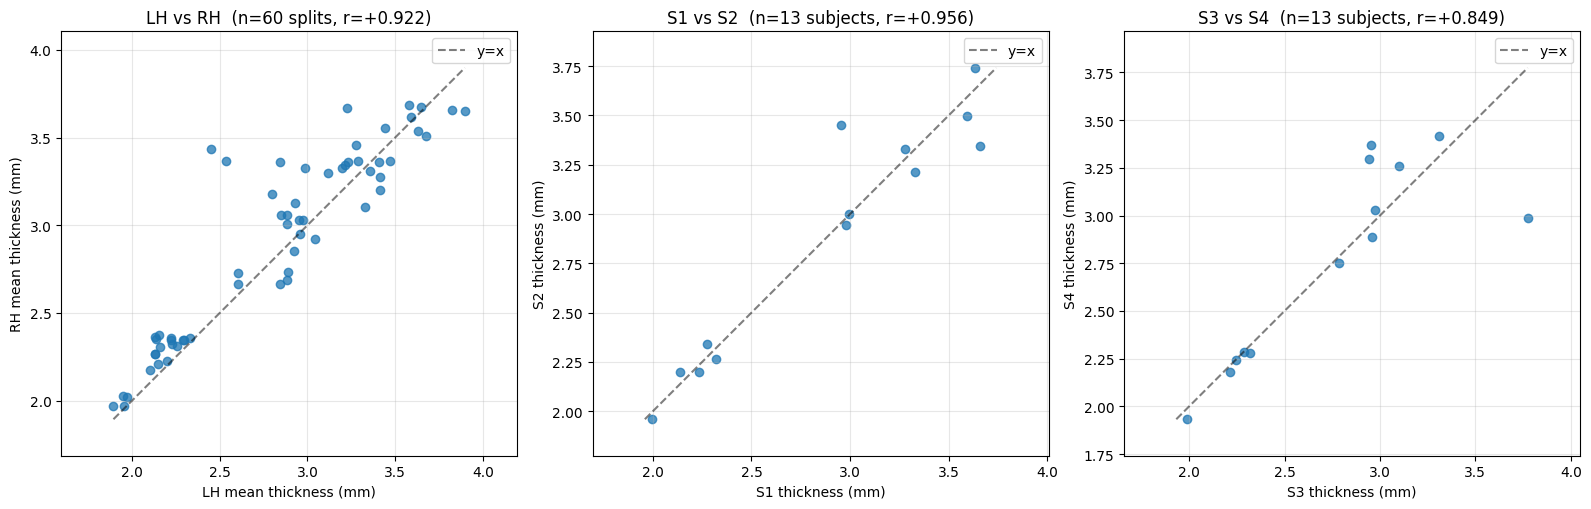

Mean |LH-RH| asymmetry = 0.163 mm
S1 vs S2: n=13, mean |Δ|=0.113 mm, max |Δ|=0.495 mm
S3 vs S4: n=13, mean |Δ|=0.162 mm, max |Δ|=0.788 mm


In [4]:
# Plot 2: agreement plots — LH vs RH (all rows), S1 vs S2 (per-subject pairs), S3 vs S4 (per-subject pairs).
# Split-pair plots use only subjects that have BOTH splits in the pair; report n comparisons.

def _agreement(ax, x, y, xlabel, ylabel, title):
    ax.scatter(x, y, alpha=0.75)
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.5, label='y=x')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_aspect('equal', adjustable='datalim')

pivot = df.pivot_table(index='subject_id', columns='split',
                       values='wholebrain_thk_mean', aggfunc='first')

fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))

# (a) LH vs RH — every subject/split row contributes
r_lhrh = df[['lh_thk_mean', 'rh_thk_mean']].corr().iloc[0, 1]
_agreement(axes[0], df['lh_thk_mean'], df['rh_thk_mean'],
           'LH mean thickness (mm)', 'RH mean thickness (mm)',
           f'LH vs RH  (n={len(df)} splits, r={r_lhrh:+.3f})')

# (b) S1 vs S2 — subjects with both
for ax, (a, b) in zip(axes[1:], [('S1', 'S2'), ('S3', 'S4')]):
    if a in pivot.columns and b in pivot.columns:
        pair = pivot[[a, b]].dropna()
        if len(pair) > 1:
            r_pair = pair.corr().iloc[0, 1]
            _agreement(ax, pair[a], pair[b],
                       f'{a} thickness (mm)', f'{b} thickness (mm)',
                       f'{a} vs {b}  (n={len(pair)} subjects, r={r_pair:+.3f})')
        else:
            ax.set_title(f'{a} vs {b}  (n={len(pair)} subjects — insufficient)')
    else:
        ax.set_title(f'{a} vs {b}  (no data)')

plt.tight_layout()
plt.savefig('../../assets/artifacts/thickness_02_lh_vs_rh.png', dpi=120)
plt.show()

print(f'Mean |LH-RH| asymmetry = {(df.lh_thk_mean - df.rh_thk_mean).abs().mean():.3f} mm')
for a, b in [('S1', 'S2'), ('S3', 'S4')]:
    pair = pivot[[a, b]].dropna()
    if len(pair):
        diff = (pair[a] - pair[b]).abs()
        print(f'{a} vs {b}: n={len(pair)}, mean |Δ|={diff.mean():.3f} mm, max |Δ|={diff.max():.3f} mm')

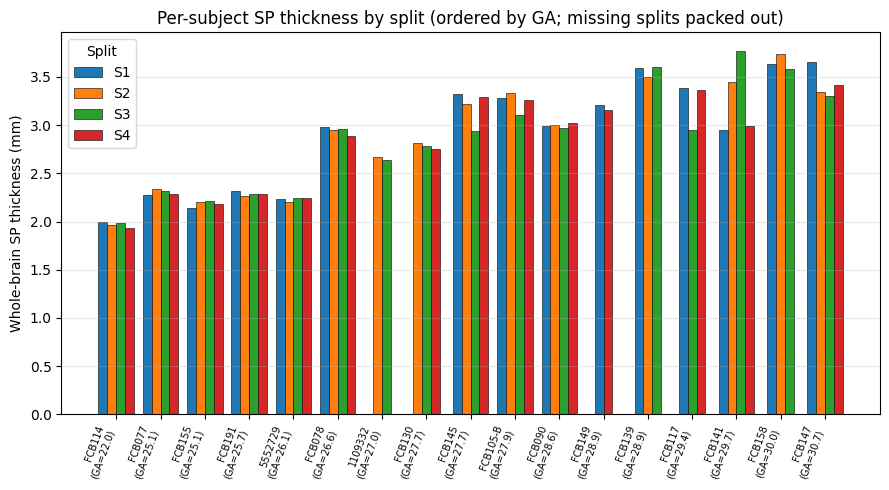

Subjects shown: 17
Splits-missing-per-subject distribution:
0    11
1     4
2     2


In [5]:
# Plot 3: bar plot ordered by GA — bars packed within each subject (no gap for missing splits)
splits = ['S1', 'S2', 'S3', 'S4']
split_colors = {'S1': '#1f77b4', 'S2': '#ff7f0e', 'S3': '#2ca02c', 'S4': '#d62728'}
subj_order = df.groupby('subject_id')['GA'].first().sort_values().index.tolist()
pivot = (df.pivot_table(index='subject_id', columns='split',
                        values='wholebrain_thk_mean', aggfunc='first')
           .reindex(subj_order))
ga_by_subj = df.groupby('subject_id')['GA'].first().reindex(subj_order)

# Fixed bar width — same regardless of how many splits a subject has.
# Within each subject, present splits are packed and the group is centered on x.
bar_w = 0.8 / len(splits)
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(subj_order))

legend_seen = set()
for i, sid in enumerate(subj_order):
    present = [s for s in splits if s in pivot.columns and pd.notna(pivot.loc[sid, s])]
    if not present:
        continue
    group_w = bar_w * len(present)
    start = x[i] - group_w / 2 + bar_w / 2
    for k, s in enumerate(present):
        lbl = s if s not in legend_seen else None
        legend_seen.add(s)
        ax.bar(start + k * bar_w, pivot.loc[sid, s], width=bar_w,
               color=split_colors[s], edgecolor='black', linewidth=0.4, label=lbl)

ax.set_xticks(x)
ax.set_xticklabels([f"{sid}\n(GA={ga:.1f})" for sid, ga in zip(subj_order, ga_by_subj)],
                   rotation=70, ha='right', fontsize=7)
ax.set_ylabel('Whole-brain SP thickness (mm)')
ax.set_title('Per-subject SP thickness by split (ordered by GA; missing splits packed out)')
# legend with consistent S1..S4 ordering
handles, labels = ax.get_legend_handles_labels()
ordered = sorted(zip(labels, handles), key=lambda lh: splits.index(lh[0]))
ax.legend([h for _, h in ordered], [l for l, _ in ordered], title='Split', loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../../assets/artifacts/thickness_03_bars_by_ga.png', dpi=120)
plt.show()
print(f'Subjects shown: {len(subj_order)}')
print('Splits-missing-per-subject distribution:')
print(pivot.isna().sum(axis=1).value_counts().sort_index().to_string())

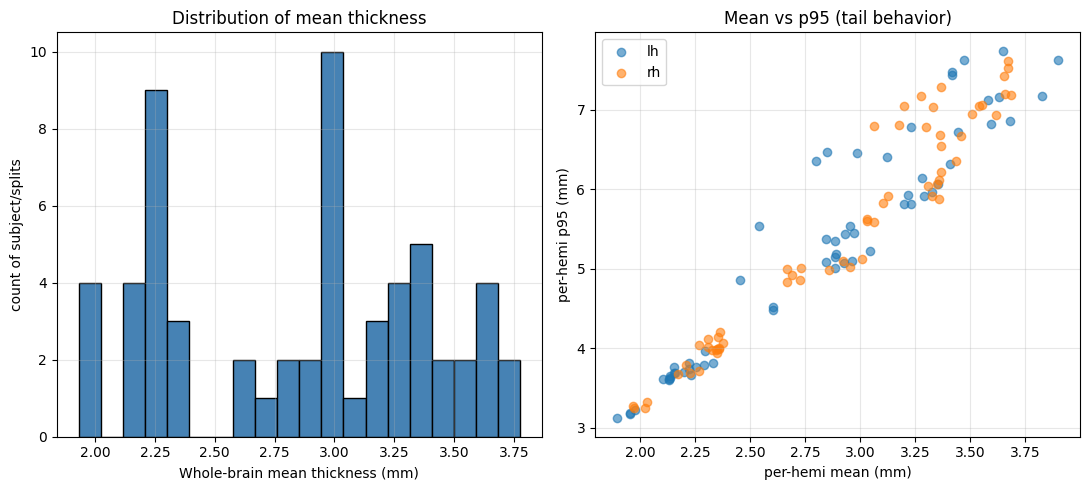

In [6]:
# Plot 4: distribution of per-vertex thickness statistics — median vs mean (should be close if symmetric)
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].hist(df['wholebrain_thk_mean'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Whole-brain mean thickness (mm)')
axes[0].set_ylabel('count of subject/splits')
axes[0].set_title('Distribution of mean thickness')
axes[0].grid(alpha=0.3)
for hemi, color in [('lh', 'tab:blue'), ('rh', 'tab:orange')]:
    axes[1].scatter(df[f'{hemi}_thk_mean'], df[f'{hemi}_thk_p95'], alpha=0.6, label=hemi, color=color)
axes[1].set_xlabel('per-hemi mean (mm)')
axes[1].set_ylabel('per-hemi p95 (mm)')
axes[1].set_title('Mean vs p95 (tail behavior)')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../../assets/artifacts/thickness_04_distributions.png', dpi=120)
plt.show()

## Thickness reliability models

Same modeling framework as the volume (`M_GA`/`M_acq`) and surface-area (`S_GA`/`S_acq`) models in `paper_models.ipynb`, applied here to **whole-brain mean SP thickness**.

Outcome: within-pair absolute thickness difference `thk_diff = |thk_a − thk_b|` (mm).
Predictors per paper: `GA`, `qa_mean` (mean quality across the pair), `stack_count`.

Two split pairs (S1-S2, S3-S4) treated as independent replications, fit separately. Read the results as *consistency across pairs*, not which pair has the highest R².

Only subjects with both splits of a pair contribute (N = 13 per pair). All thickness subjects are GA ≤ 32 wk, so no GA restriction is needed here.

Diagnostics (predicted vs actual, residuals vs fitted, QQ-plot, residuals vs GA) are shown directly under each model's forest plot.

### Build per-pair analysis frames

The comparative metrics live directly in `thickness_audit.csv` (columns `split_pair`, `thk_diff`, `thk_mean`, `apd_thk`) alongside the acquisition covariates (`qa_mean`, `stack_count`) — so the models read straight from that one file. Each split row carries its pair's values; we filter by `split_pair` and keep one row per subject-session.

In [7]:
import sys
from pathlib import Path

import statsmodels.api as sm
from IPython.display import display

sys.path.insert(0, '..')  # src/ — for slides_helpers
from slides_helpers import diagnostics_grid, fit_and_present, model_comparison_table

ASSETS = Path('../../assets/artifacts')

# thickness_audit.csv now carries the comparative columns directly
audit = pd.read_csv('../../data/thickness_audit.csv')


def get_pair(label):
    """One row per subject-session for a split pair, dropping incomplete pairs."""
    return (
        audit[audit['split_pair'] == label]
        .drop_duplicates(['subject_id', 'session_id'])
        .dropna(subset=['thk_diff'])
        .reset_index(drop=True)
    )


s12 = get_pair('S1-S2')
s34 = get_pair('S3-S4')

print('S1-S2 frame:', s12.shape, '| S3-S4 frame:', s34.shape)
display(s12[['subject_id', 'session_id', 'GA', 'thk_diff', 'thk_mean',
             'apd_thk', 'qa_mean', 'stack_count']].head(3))

S1-S2 frame: (13, 26) | S3-S4 frame: (13, 26)


,subject_id,session_id,GA,thk_diff,thk_mean,apd_thk,qa_mean,stack_count
0,FCB145,2019.03.20-032Y-MR_EI_Fetal_Neuro-29197,27.71,0.113109,3.271956,3.456909,0.83,3
1,FCB191,MR-EI_Fetal_Neuro-26708033-20230113,25.71,0.056648,2.291105,2.472508,0.53,5
2,FCB139,2019.01.31-032Y-MR_EI_Fetal_Neuro-29172,28.86,0.093669,3.545375,2.642015,0.85,5


### Layer 1 — Reliability magnitude (descriptive)

Paper-style summary: absolute and absolute-percent thickness difference (mean ± SD, range) for both pairs.

In [8]:
def reliability_row(df, pair):
    a = df['thk_diff'].dropna()
    p = df['apd_thk'].dropna()
    return {
        'metric': 'WB SP thickness (mm)', 'pair': pair, 'N': len(a),
        'abs_mean': a.mean().round(3), 'abs_sd': a.std().round(3),
        'abs_range': f'[{a.min():.3f}, {a.max():.3f}]',
        'APD_mean': p.mean().round(2), 'APD_sd': p.std().round(2),
        'APD_range': f'[{p.min():.2f}, {p.max():.2f}]',
    }

reliability_table = pd.DataFrame([
    reliability_row(s12, 'S1-S2'),
    reliability_row(s34, 'S3-S4'),
])
display(reliability_table)

,metric,pair,N,abs_mean,abs_sd,abs_range,APD_mean,APD_sd,APD_range
0,WB SP thickness (mm),S1-S2,13,0.113,0.138,"[0.009, 0.495]",3.70,4.10,"[0.29, 15.46]"
1,WB SP thickness (mm),S3-S4,13,0.162,0.228,"[0.000, 0.788]",5.19,6.77,"[0.00, 23.30]"


### Thickness models

Same two specifications as the volume/surface models, each fit independently for S1-S2 and S3-S4:
1. **T_GA** (baseline): `thk_diff ~ GA`
2. **T_acq** (paper-style acquisition factors): `thk_diff ~ GA + qa_mean + stack_count`


===  | S1-S2 | R²=0.313 | F=5.00 | p=0.0470 | N=13 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-0.749,0.387,-1.94,0.079,-1.6,0.10,
GA,0.032,0.014,2.24,0.047,0.0,0.06,*



===  | S3-S4 | R²=0.276 | F=4.19 | p=0.0652 | N=13 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-1.228,0.681,-1.80,0.099,-2.73,0.27,
GA,0.051,0.025,2.05,0.065,-0.00,0.11,


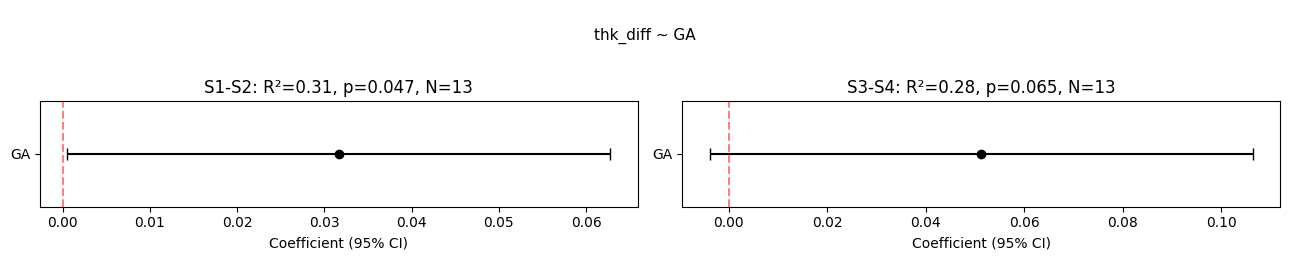

In [9]:
thk_results = {}

thk_results['T_GA (thk)'] = fit_and_present(
    'thk_diff', ['GA'], s12, s34,
    '', 'thk_T_GA', ASSETS, save_tables=False,
)


[T_GA — WB SP thickness baseline] S1-S2 — top 3 outliers (|studentized residual|):
  1. FCB141/2019.04.03-032Y-MR_EI_Fetal_Neuro-29199  studentized_resid=+2.78  resid=+0.303  fitted=0.192  actual=0.495
  2. FCB090/2016.07.24-029Y-MR_EI_Fetal_Neuro-12836  studentized_resid=-1.30  resid=-0.147  fitted=0.156  actual=0.00872
  3. FCB114/2017.06.26-027Y-MR_EI_Fetal_Neuro-17914  studentized_resid=+1.03  resid=+0.0904  fitted=-0.0523  actual=0.038

[T_GA — WB SP thickness baseline] S3-S4 — top 3 outliers (|studentized residual|):
  1. FCB141/2019.04.03-032Y-MR_EI_Fetal_Neuro-29199  studentized_resid=+2.68  resid=+0.492  fitted=0.296  actual=0.788
  2. FCB147/2019.05.08-036Y-MR_EI_Fetal_Neuro-29187  studentized_resid=-1.38  resid=-0.238  fitted=0.347  actual=0.109
  3. FCB114/2017.06.26-027Y-MR_EI_Fetal_Neuro-17914  studentized_resid=+1.06  resid=+0.157  fitted=-0.0995  actual=0.0572


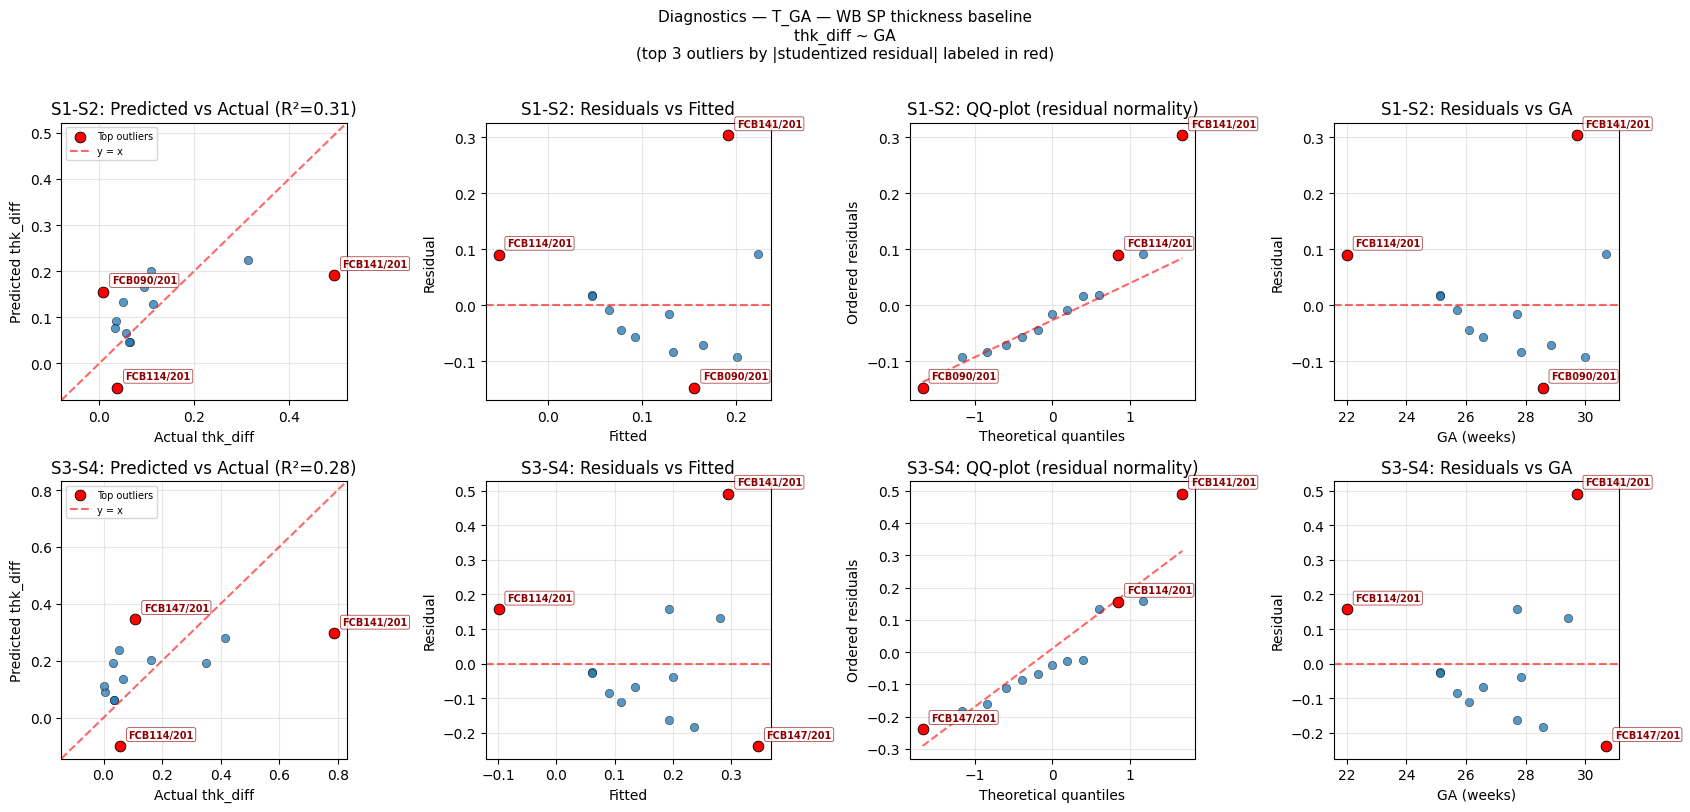

In [10]:
diagnostics_grid(
    thk_results['T_GA (thk)'], s12, s34,
    'thk_diff', ['GA'],
    'T_GA — WB SP thickness baseline',
)
plt.show()


===  | S1-S2 | R²=0.326 | F=1.45 | p=0.2910 | N=13 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-0.621,0.517,-1.20,0.260,-1.79,0.55,
GA,0.033,0.016,2.08,0.067,-0.00,0.07,
qa_mean,-0.163,0.398,-0.41,0.693,-1.06,0.74,
stack_count,-0.007,0.018,-0.37,0.721,-0.05,0.03,



===  | S3-S4 | R²=0.322 | F=1.43 | p=0.2984 | N=13 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-1.000,0.810,-1.23,0.248,-2.83,0.83,
GA,0.052,0.027,1.94,0.084,-0.01,0.11,
qa_mean,-0.159,0.444,-0.36,0.729,-1.16,0.85,
stack_count,-0.019,0.025,-0.78,0.455,-0.08,0.04,


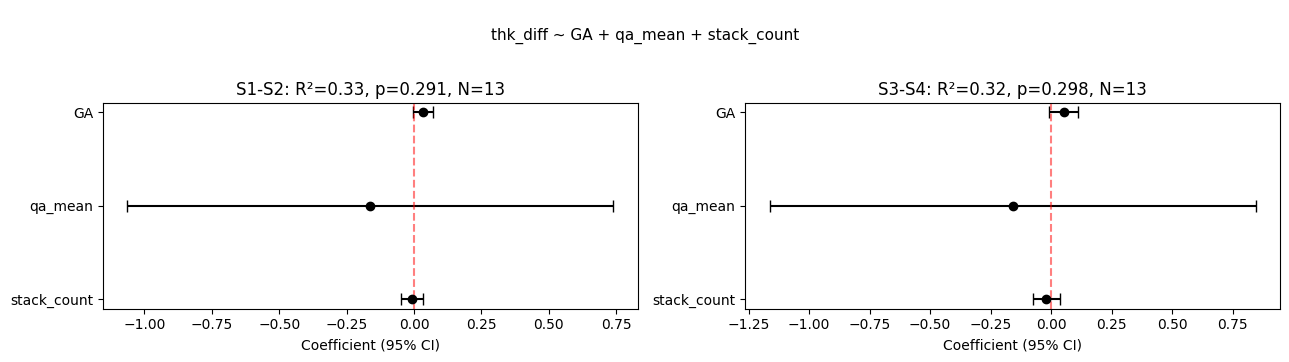

In [11]:
thk_results['T_acq (thk)'] = fit_and_present(
    'thk_diff', ['GA', 'qa_mean', 'stack_count'], s12, s34,
    '', 'thk_T_acq', ASSETS, save_tables=False,
)


[T_acq — WB SP thickness + acquisition factors] S1-S2 — top 3 outliers (|studentized residual|):
  1. FCB141/2019.04.03-032Y-MR_EI_Fetal_Neuro-29199  studentized_resid=+2.53  resid=+0.288  fitted=0.207  actual=0.495
  2. FCB090/2016.07.24-029Y-MR_EI_Fetal_Neuro-12836  studentized_resid=-1.29  resid=-0.148  fitted=0.157  actual=0.00872
  3. FCB147/2019.05.08-036Y-MR_EI_Fetal_Neuro-29187  studentized_resid=+1.04  resid=+0.107  fitted=0.208  actual=0.314

[T_acq — WB SP thickness + acquisition factors] S3-S4 — top 3 outliers (|studentized residual|):
  1. FCB141/2019.04.03-032Y-MR_EI_Fetal_Neuro-29199  studentized_resid=+2.48  resid=+0.483  fitted=0.305  actual=0.788
  2. FCB114/2017.06.26-027Y-MR_EI_Fetal_Neuro-17914  studentized_resid=+1.46  resid=+0.184  fitted=-0.127  actual=0.0572
  3. FCB130/2018.11.02-030Y-MR_EI_Fetal_Neuro-29188  studentized_resid=-1.31  resid=-0.236  fitted=0.268  actual=0.0313


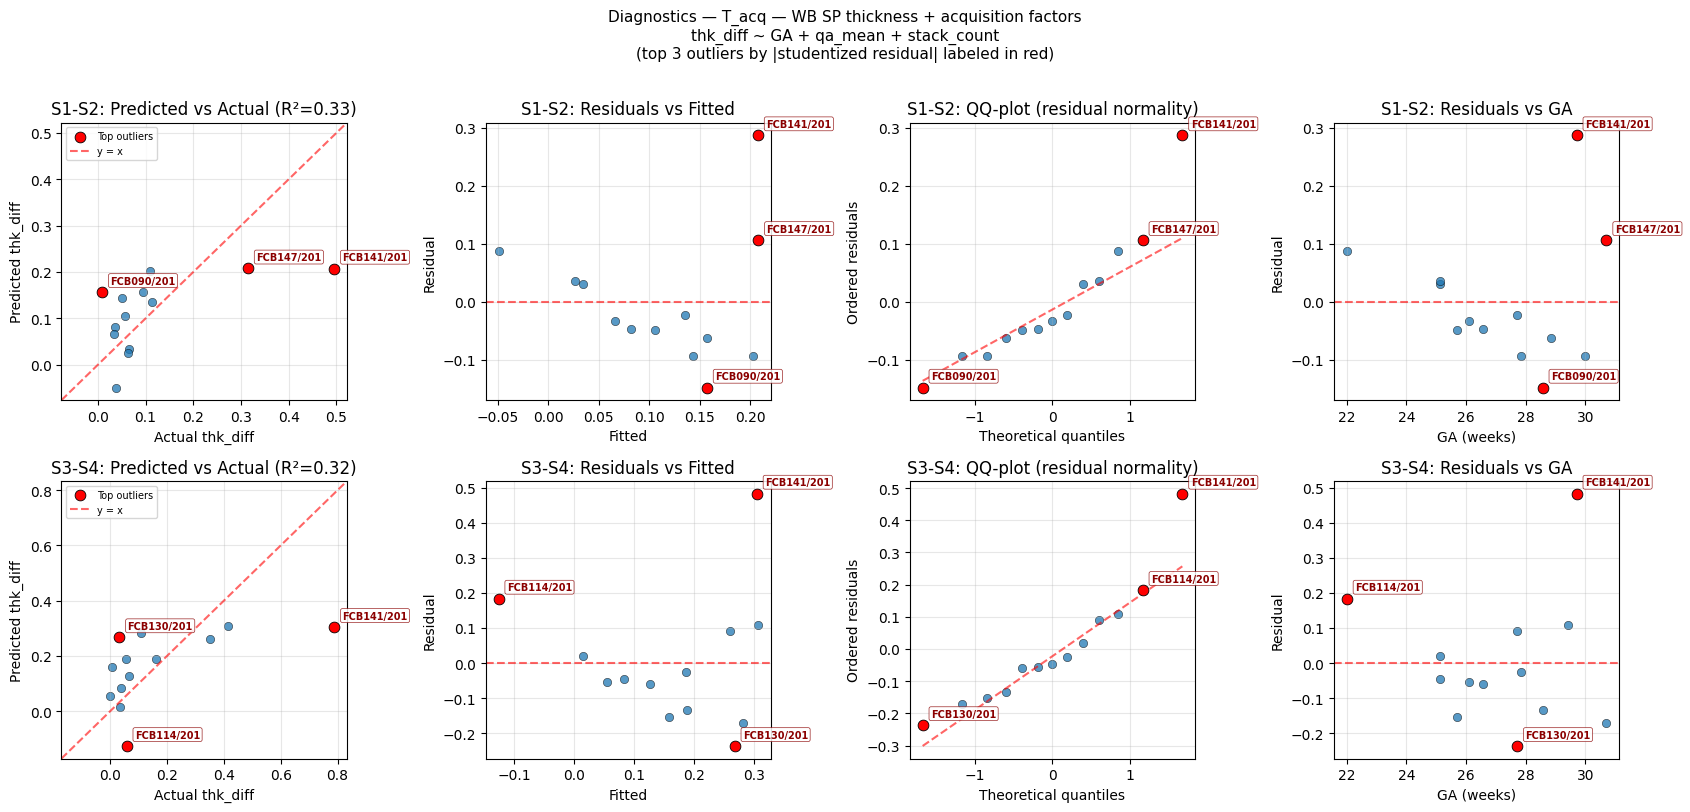

In [12]:
diagnostics_grid(
    thk_results['T_acq (thk)'], s12, s34,
    'thk_diff', ['GA', 'qa_mean', 'stack_count'],
    'T_acq — WB SP thickness + acquisition factors',
)
plt.show()

### Cross-model comparison

Side-by-side R², GA effect across both thickness models × both pairs. Read column-wise: a model is *consistent* if its R², GA-sign, and GA-significance look similar across S1-S2 and S3-S4.

,model,pair,N,R2,adj_R2,F_p,GA_coef,GA_p
0,T_GA (thk),S1-S2,13,0.313,0.250,0.0470,0.032,0.0470
1,T_GA (thk),S3-S4,13,0.276,0.210,0.0652,0.051,0.0652
2,T_acq (thk),S1-S2,13,0.326,0.102,0.2910,0.033,0.0672
3,T_acq (thk),S3-S4,13,0.322,0.096,0.2984,0.052,0.0841


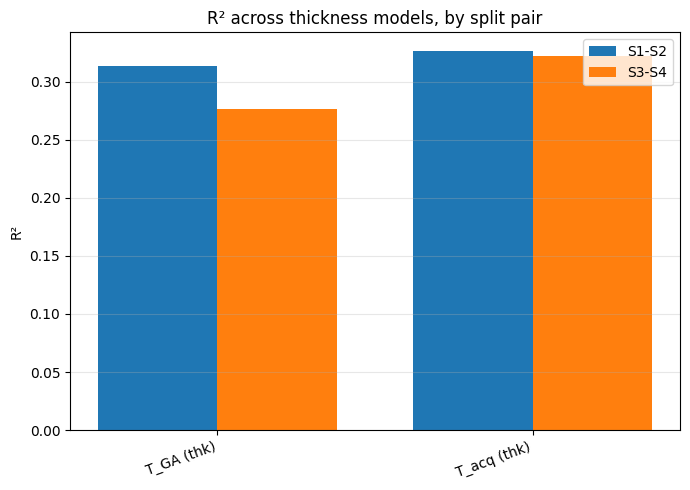

In [13]:
comparison = model_comparison_table(thk_results)
display(comparison)

# R^2 bar chart, paired by split
fig, ax = plt.subplots(figsize=(7, 5))
models = comparison['model'].unique()
x = np.arange(len(models))
w = 0.38
for i, pair in enumerate(['S1-S2', 'S3-S4']):
    sub = comparison[comparison['pair'] == pair].set_index('model').reindex(models)
    ax.bar(x + (i - 0.5) * w, sub['R2'], width=w, label=pair)
ax.set_xticks(x); ax.set_xticklabels(models, rotation=20, ha='right')
ax.set_ylabel('R²'); ax.set_title('R² across thickness models, by split pair')
ax.legend(); ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(ASSETS / 'thickness_model_comparison_R2.png', dpi=130, bbox_inches='tight')
plt.show()

## Sensitivity — drop the most common outliers

The cross-model outlier scan in `paper_models.ipynb` flagged **FCB141** and **FCB114** as among the most frequently-flagged subjects across the volume/surface/thickness fits. Here the thickness models are refit with those two subjects removed (N = 13 → 11 per pair) to check whether the GA signal is robust to them.

Read it the same way: *consistency across pairs*, and whether `R²` / GA-coefficient / GA-significance hold up once the outliers are gone.

In [14]:
DROP = ['FCB141', 'FCB114']

s12_f = s12[~s12['subject_id'].isin(DROP)].reset_index(drop=True)
s34_f = s34[~s34['subject_id'].isin(DROP)].reset_index(drop=True)

print('Dropped:', DROP)
print('Filtered frames — S1-S2:', s12_f.shape, '| S3-S4:', s34_f.shape)

Dropped: ['FCB141', 'FCB114']
Filtered frames — S1-S2: (11, 26) | S3-S4: (11, 26)



===  | S1-S2 | R²=0.390 | F=5.75 | p=0.0400 | N=11 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-0.652,0.308,-2.12,0.063,-1.35,0.05,
GA,0.027,0.011,2.40,0.040,0.00,0.05,*



===  | S3-S4 | R²=0.272 | F=3.36 | p=0.0999 | N=11 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-1.003,0.611,-1.64,0.135,-2.39,0.38,
GA,0.041,0.022,1.83,0.100,-0.01,0.09,


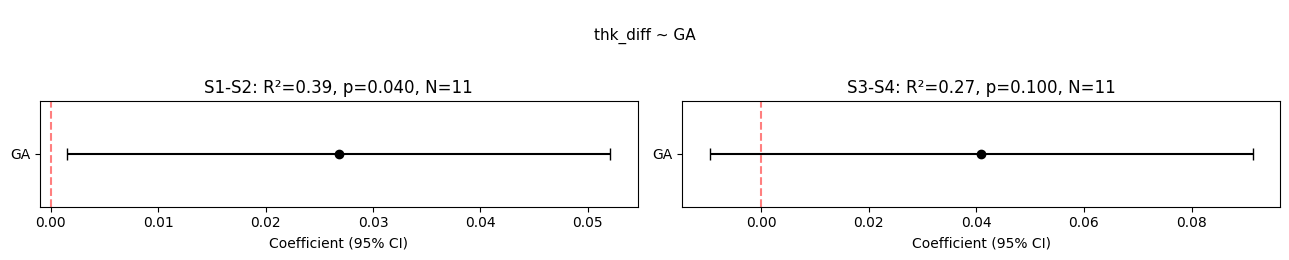

In [15]:
thk_results_f = {}

thk_results_f['T_GA (thk, -outliers)'] = fit_and_present(
    'thk_diff', ['GA'], s12_f, s34_f,
    '', 'thk_T_GA_filt', ASSETS, save_tables=False,
)


[T_GA — WB SP thickness (FCB141/FCB114 dropped)] S1-S2 — top 3 outliers (|studentized residual|):
  1. FCB147/2019.05.08-036Y-MR_EI_Fetal_Neuro-29187  studentized_resid=+2.65  resid=+0.142  fitted=0.172  actual=0.314
  2. FCB090/2016.07.24-029Y-MR_EI_Fetal_Neuro-12836  studentized_resid=-1.66  resid=-0.106  fitted=0.115  actual=0.00872
  3. FCB158/2019.07.07-034Y-MR_EI_Fetal_Neuro-29182  studentized_resid=-0.76  resid=-0.0443  fitted=0.153  actual=0.109

[T_GA — WB SP thickness (FCB141/FCB114 dropped)] S3-S4 — top 3 outliers (|studentized residual|):
  1. FCB117/2018.03.01-032Y-MR_EI_Fetal_Neuro-18053  studentized_resid=+1.92  resid=+0.214  fitted=0.201  actual=0.415
  2. FCB145/2019.03.20-032Y-MR_EI_Fetal_Neuro-29197  studentized_resid=+1.83  resid=+0.22  fitted=0.13  actual=0.351
  3. FCB147/2019.05.08-036Y-MR_EI_Fetal_Neuro-29187  studentized_resid=-1.53  resid=-0.144  fitted=0.253  actual=0.109


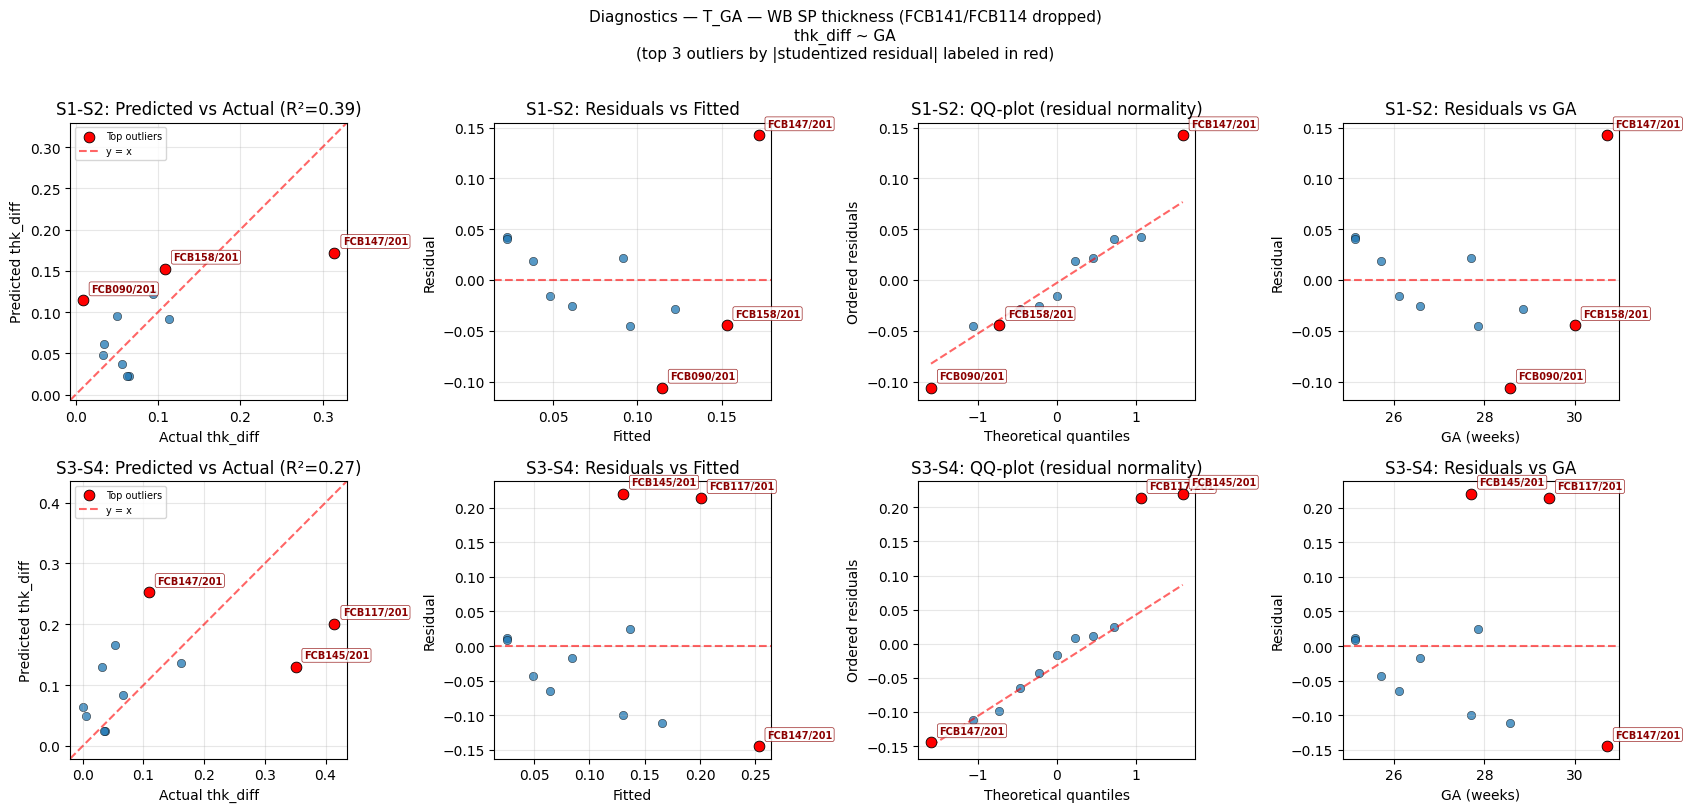

In [16]:
diagnostics_grid(
    thk_results_f['T_GA (thk, -outliers)'], s12_f, s34_f,
    'thk_diff', ['GA'],
    'T_GA — WB SP thickness (FCB141/FCB114 dropped)',
)
plt.show()


===  | S1-S2 | R²=0.449 | F=1.91 | p=0.2172 | N=11 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-0.817,0.383,-2.13,0.070,-1.72,0.09,
GA,0.027,0.013,2.13,0.071,-0.00,0.06,
qa_mean,0.197,0.238,0.83,0.435,-0.37,0.76,
stack_count,0.003,0.011,0.28,0.788,-0.02,0.03,



===  | S3-S4 | R²=0.423 | F=1.71 | p=0.2517 | N=11 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-1.029,0.789,-1.30,0.234,-2.89,0.84,
GA,0.050,0.026,1.91,0.098,-0.01,0.11,
qa_mean,-0.100,0.302,-0.33,0.751,-0.81,0.62,
stack_count,-0.021,0.016,-1.35,0.220,-0.06,0.02,


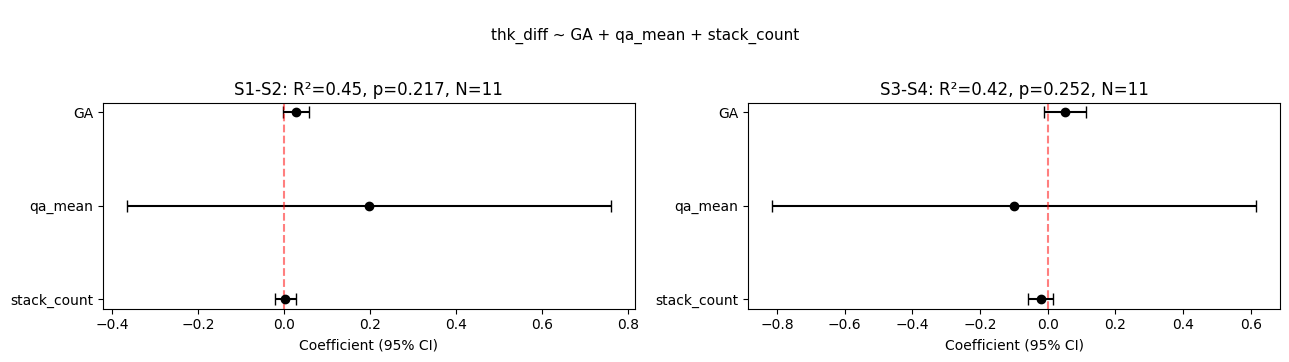

In [17]:
thk_results_f['T_acq (thk, -outliers)'] = fit_and_present(
    'thk_diff', ['GA', 'qa_mean', 'stack_count'], s12_f, s34_f,
    '', 'thk_T_acq_filt', ASSETS, save_tables=False,
)


[T_acq — WB SP thickness + acquisition (FCB141/FCB114 dropped)] S1-S2 — top 3 outliers (|studentized residual|):
  1. FCB147/2019.05.08-036Y-MR_EI_Fetal_Neuro-29187  studentized_resid=+2.50  resid=+0.136  fitted=0.178  actual=0.314
  2. FCB191/MR-EI_Fetal_Neuro-26708033-20230113  studentized_resid=+1.67  resid=+0.0592  fitted=-0.00251  actual=0.0566
  3. FCB090/2016.07.24-029Y-MR_EI_Fetal_Neuro-12836  studentized_resid=-1.40  resid=-0.0878  fitted=0.0965  actual=0.00872

[T_acq — WB SP thickness + acquisition (FCB141/FCB114 dropped)] S3-S4 — top 3 outliers (|studentized residual|):
  1. FCB117/2018.03.01-032Y-MR_EI_Fetal_Neuro-18053  studentized_resid=+2.10  resid=+0.192  fitted=0.223  actual=0.415
  2. FCB130/2018.11.02-030Y-MR_EI_Fetal_Neuro-29188  studentized_resid=-1.63  resid=-0.172  fitted=0.203  actual=0.0313
  3. FCB145/2019.03.20-032Y-MR_EI_Fetal_Neuro-29197  studentized_resid=+1.57  resid=+0.134  fitted=0.216  actual=0.351


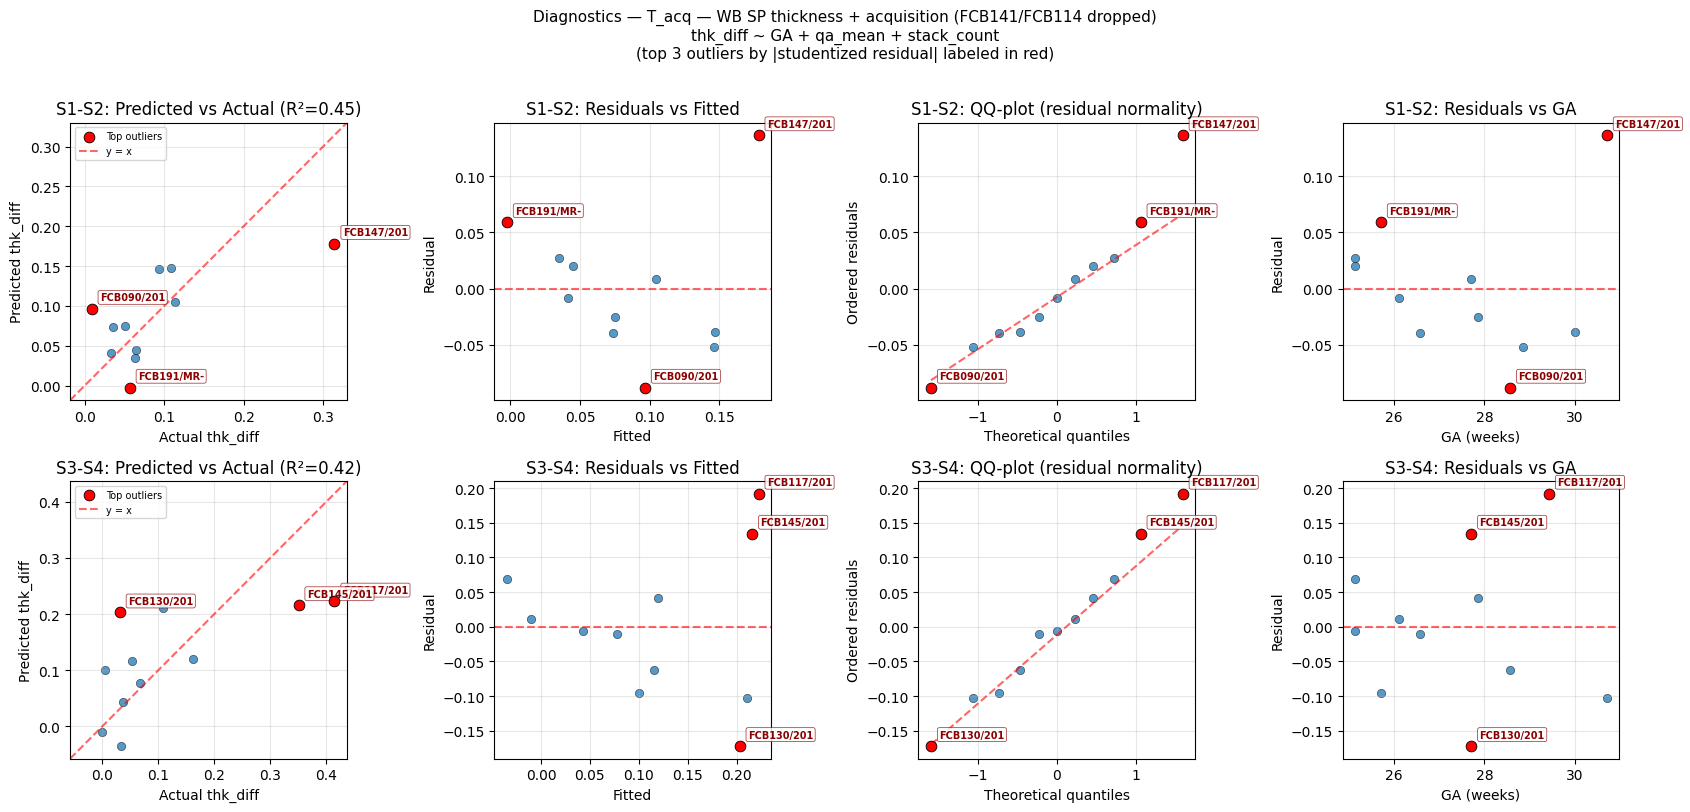

In [18]:
diagnostics_grid(
    thk_results_f['T_acq (thk, -outliers)'], s12_f, s34_f,
    'thk_diff', ['GA', 'qa_mean', 'stack_count'],
    'T_acq — WB SP thickness + acquisition (FCB141/FCB114 dropped)',
)
plt.show()

### Full sample vs. outliers-dropped

Side-by-side comparison of the two thickness models fit on the full sample (N = 13) and with FCB141/FCB114 removed (N = 11).

In [19]:
full = model_comparison_table(thk_results).assign(sample='full (N=13)')
filt = model_comparison_table(thk_results_f).assign(sample='drop FCB141/FCB114 (N=11)')
filt['model'] = filt['model'].str.replace(' (thk, -outliers)', ' (thk)', regex=False)

side = (pd.concat([full, filt], ignore_index=True)
          .sort_values(['model', 'pair', 'sample'])
          .reset_index(drop=True))
display(side[['model', 'pair', 'sample', 'N', 'R2', 'adj_R2', 'F_p', 'GA_coef', 'GA_p']])

,model,pair,sample,N,R2,adj_R2,F_p,GA_coef,GA_p
0,T_GA (thk),S1-S2,drop FCB141/FCB114 (N=11),11,0.390,0.322,0.0400,0.027,0.0400
1,T_GA (thk),S1-S2,full (N=13),13,0.313,0.250,0.0470,0.032,0.0470
2,T_GA (thk),S3-S4,drop FCB141/FCB114 (N=11),11,0.272,0.191,0.0999,0.041,0.0999
3,T_GA (thk),S3-S4,full (N=13),13,0.276,0.210,0.0652,0.051,0.0652
4,T_acq (thk),S1-S2,drop FCB141/FCB114 (N=11),11,0.449,0.214,0.2172,0.027,0.0710
5,T_acq (thk),S1-S2,full (N=13),13,0.326,0.102,0.2910,0.033,0.0672
6,T_acq (thk),S3-S4,drop FCB141/FCB114 (N=11),11,0.423,0.175,0.2517,0.050,0.0983
7,T_acq (thk),S3-S4,full (N=13),13,0.322,0.096,0.2984,0.052,0.0841
